In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [5]:
DATA_DIR = "Data"

TRAIN_FILE = f"{DATA_DIR}/train_selected.csv"
VAL_FILE = f"{DATA_DIR}/validation_selected.csv"
TEST_FILE = f"{DATA_DIR}/test_selected.csv"

train_df = pd.read_csv(TRAIN_FILE)
val_df = pd.read_csv(VAL_FILE)
test_df = pd.read_csv(TEST_FILE)

print("=" * 70)
print("DATASET SHAPES")
print("=" * 70)

print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print(f"Test       : {test_df.shape}")

DATASET SHAPES
Train      : (81977, 17)
Validation : (17567, 17)
Test       : (17567, 17)


In [6]:
TARGET = "label"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_val = val_df.drop(columns=[TARGET])
y_val = val_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (81977, 16)
y_train: (81977,)
X_val  : (17567, 16)
y_val  : (17567,)
X_test : (17567, 16)
y_test : (17567,)


In [7]:
print("=" * 70)
print("FEATURE CONSISTENCY CHECK")
print("=" * 70)

print("Train == Validation:",
      list(X_train.columns) == list(X_val.columns))

print("Train == Test      :",
      list(X_train.columns) == list(X_test.columns))

print("\nFeatures:")
for i, feature in enumerate(X_train.columns, 1):
    print(f"{i:2}. {feature}")

FEATURE CONSISTENCY CHECK
Train == Validation: True
Train == Test      : True

Features:
 1. gnomad_exome_hom_count
 2. vep_impact
 3. gnomad_genome_hom_count
 4. protein_length
 5. Molecular consequence
 6. vep_variant_class
 7. is_nonsense
 8. relative_protein_position
 9. vep_protein_position
10. protein_position_valid
11. protein_change_available
12. n_region
13. distance_to_nearest_region
14. vep_transcript_count
15. n_domain
16. n_binding_site


In [8]:
print("=" * 70)
print("MODEL INPUT QUALITY CHECK")
print("=" * 70)

for name, X in [
    ("TRAIN", X_train),
    ("VALIDATION", X_val),
    ("TEST", X_test)
]:
    
    nan_count = X.isna().sum().sum()
    inf_count = np.isinf(X.select_dtypes(include=np.number)).sum().sum()
    
    print(
        f"{name:<12} "
        f"NaN = {nan_count:,} | "
        f"Inf = {inf_count:,}"
    )

MODEL INPUT QUALITY CHECK
TRAIN        NaN = 0 | Inf = 0
VALIDATION   NaN = 0 | Inf = 0
TEST         NaN = 0 | Inf = 0


In [9]:
print("=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

for name, y in [
    ("TRAIN", y_train),
    ("VALIDATION", y_val),
    ("TEST", y_test)
]:
    
    counts = y.value_counts().sort_index()
    percentages = y.value_counts(normalize=True).sort_index() * 100
    
    print(f"\n{name}")
    
    for label in counts.index:
        print(
            f"  Class {label}: "
            f"{counts[label]:,} "
            f"({percentages[label]:.2f}%)"
        )

CLASS DISTRIBUTION

TRAIN
  Class 0: 25,728 (31.38%)
  Class 1: 56,249 (68.62%)

VALIDATION
  Class 0: 5,513 (31.38%)
  Class 1: 12,054 (68.62%)

TEST
  Class 0: 5,514 (31.39%)
  Class 1: 12,053 (68.61%)


In [10]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
gnomad_exome_hom_count,81977.0,6.659889e-17,1.000006,-0.111496,-0.111496,-0.111496,-0.111496,15.707419
vep_impact,81977.0,5.007136e-01,0.500003,0.000000,0.000000,1.000000,1.000000,1.000000
gnomad_genome_hom_count,81977.0,3.283661e-17,1.000006,-0.114978,-0.114978,-0.114978,-0.114978,15.795847
protein_length,81977.0,2.110557e-17,1.000006,-0.688989,-0.463324,-0.270151,0.180289,14.577450
Molecular consequence,81977.0,3.911341e-01,0.488007,0.000000,0.000000,0.000000,1.000000,1.000000
vep_variant_class,81977.0,7.725460e-01,0.419191,0.000000,1.000000,1.000000,1.000000,1.000000
is_nonsense,81977.0,5.146379e-17,1.000006,-0.492069,-0.492069,-0.492069,-0.492069,2.032234
relative_protein_position,81977.0,-2.563547e-16,1.000006,-1.913655,-0.727601,-0.024571,0.734661,6.186524
vep_protein_position,81977.0,1.633840e-17,1.000006,-0.775194,-0.506395,-0.295836,0.081603,16.498503
protein_position_valid,81977.0,-2.534680e-16,1.000006,-2.156946,0.463618,0.463618,0.463618,0.463618


In [11]:
def evaluate_model(model, X, y, model_name="Model"):
    
    # Predictions
    y_pred = model.predict(X)
    
    # Probabilities
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)[:, 1]
    else:
        y_prob = model.decision_function(X)
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1": f1_score(y, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, y_prob),
        "PR-AUC": average_precision_score(y, y_prob),
        "MCC": matthews_corrcoef(y, y_pred)
    }
    
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    
    for metric, value in metrics.items():
        if metric != "Model":
            print(f"{metric:<20}: {value:.4f}")
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y, y_pred, digits=4))
    
    return metrics

In [12]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [13]:
logistic_val_metrics = evaluate_model(
    logistic_model,
    X_val,
    y_val,
    model_name="Logistic Regression"
)

Logistic Regression
Accuracy            : 0.8166
Balanced Accuracy   : 0.8603
Precision           : 0.9865
Recall              : 0.7429
F1                  : 0.8475
ROC-AUC             : 0.9319
PR-AUC              : 0.9698
MCC                 : 0.6692

Confusion Matrix:
[[5390  123]
 [3099 8955]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6349    0.9777    0.7699      5513
           1     0.9865    0.7429    0.8475     12054

    accuracy                         0.8166     17567
   macro avg     0.8107    0.8603    0.8087     17567
weighted avg     0.8761    0.8166    0.8232     17567



In [14]:
results = []

results.append(logistic_val_metrics)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
0,Logistic Regression,0.816588,0.860298,0.986451,0.742907,0.84753,0.931872,0.969847,0.669157


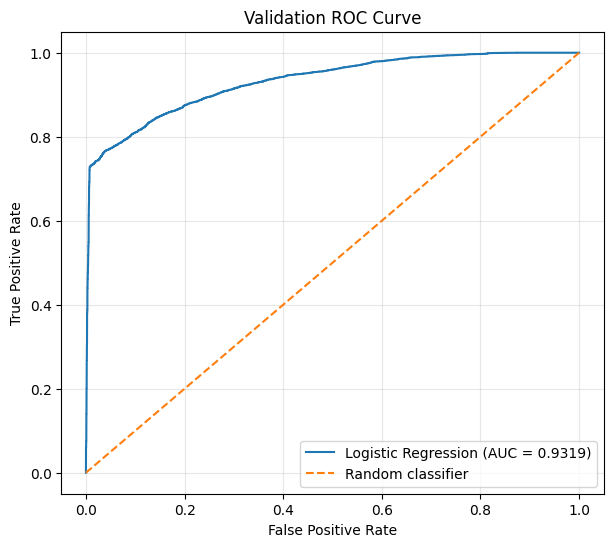

In [15]:
y_val_prob_lr = logistic_model.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_val,
    y_val_prob_lr
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_val, y_val_prob_lr):.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

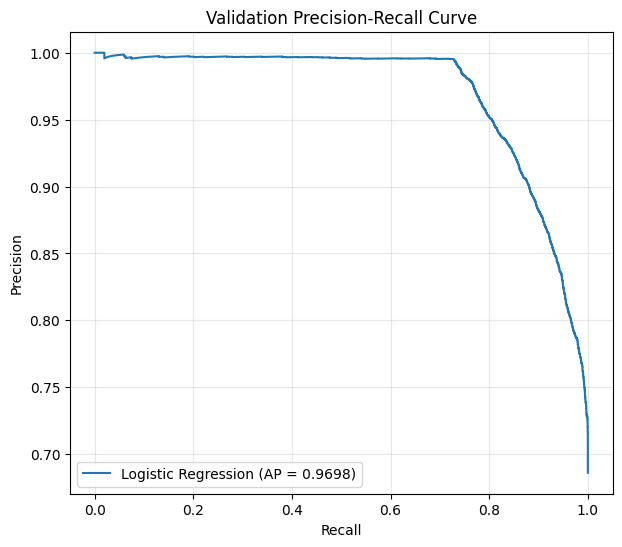

In [16]:
precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_prob_lr
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    label=f"Logistic Regression (AP = {average_precision_score(y_val, y_val_prob_lr):.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [17]:
coefficient_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": logistic_model.coef_[0]
})

coefficient_df["absolute_coefficient"] = (
    coefficient_df["coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "absolute_coefficient",
    ascending=False
)

coefficient_df

,feature,coefficient,absolute_coefficient
2,gnomad_genome_hom_count,-20.840282,20.840282
0,gnomad_exome_hom_count,-13.425063,13.425063
1,vep_impact,5.652383,5.652383
5,vep_variant_class,-1.194975,1.194975
3,protein_length,-0.480257,0.480257
14,n_domain,0.451227,0.451227
9,protein_position_valid,0.408098,0.408098
10,protein_change_available,-0.396148,0.396148
11,n_region,-0.311794,0.311794
4,Molecular consequence,0.296650,0.296650


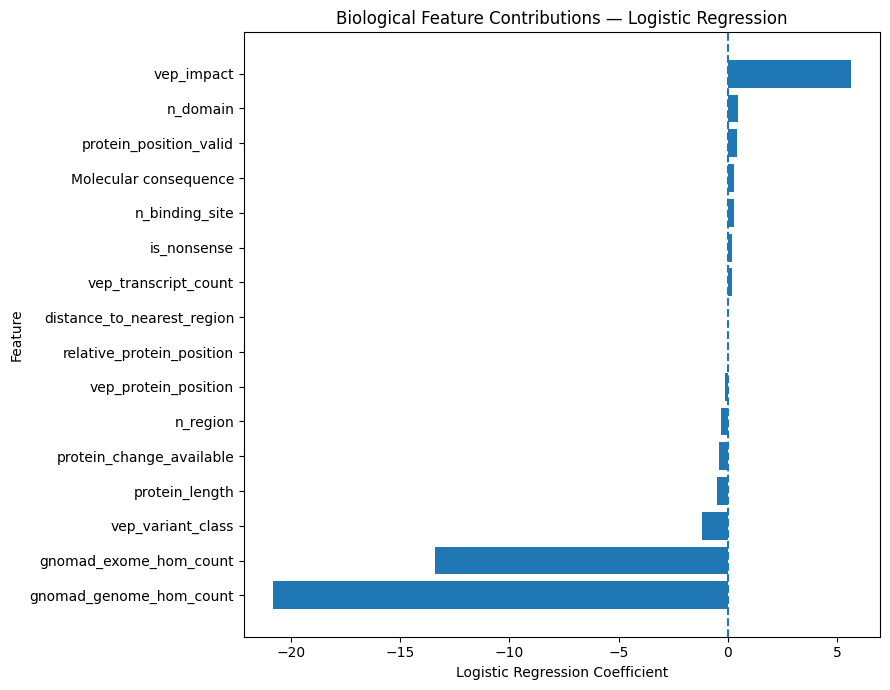

In [18]:
plot_df = coefficient_df.sort_values(
    "coefficient"
)

plt.figure(figsize=(9, 7))

plt.barh(
    plot_df["feature"],
    plot_df["coefficient"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Biological Feature Contributions — Logistic Regression")

plt.tight_layout()
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training complete.")

Random Forest training complete.


In [21]:
rf_val_metrics = evaluate_model(
    rf_model,
    X_val,
    y_val,
    model_name="Random Forest"
)

Random Forest
Accuracy            : 0.9654
Balanced Accuracy   : 0.9562
Precision           : 0.9691
Recall              : 0.9808
F1                  : 0.9749
ROC-AUC             : 0.9929
PR-AUC              : 0.9958
MCC                 : 0.9192

Confusion Matrix:
[[ 5136   377]
 [  231 11823]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9570    0.9316    0.9441      5513
           1     0.9691    0.9808    0.9749     12054

    accuracy                         0.9654     17567
   macro avg     0.9630    0.9562    0.9595     17567
weighted avg     0.9653    0.9654    0.9653     17567



In [22]:
results.append(rf_val_metrics)

results_df = pd.DataFrame(results)

results_df.sort_values(
    "ROC-AUC",
    ascending=False
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
1,Random Forest,0.965390,0.956226,0.969098,0.980836,0.974932,0.992917,0.995798,0.919230
0,Logistic Regression,0.816588,0.860298,0.986451,0.742907,0.847530,0.931872,0.969847,0.669157


In [23]:
rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

rf_importance

,feature,importance
0,gnomad_exome_hom_count,0.241619
1,vep_impact,0.219854
2,gnomad_genome_hom_count,0.116171
3,Molecular consequence,0.077477
4,protein_length,0.049117
5,vep_protein_position,0.039362
6,n_region,0.038259
7,relative_protein_position,0.036946
8,vep_transcript_count,0.031981
9,distance_to_nearest_region,0.031814


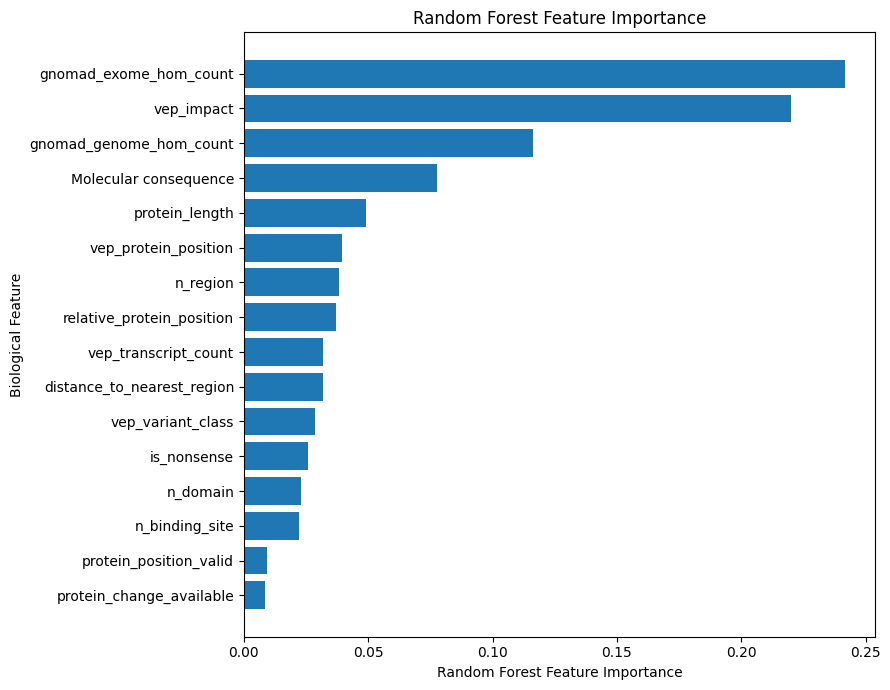

In [24]:
plt.figure(figsize=(9, 7))

plot_df = rf_importance.sort_values(
    "importance"
)

plt.barh(
    plot_df["feature"],
    plot_df["importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Biological Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import roc_auc_score

single_feature_results = []

for feature in X_train.columns:
    
    # Train a simple one-feature logistic model
    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
    
    model.fit(
        X_train[[feature]],
        y_train
    )
    
    val_prob = model.predict_proba(
        X_val[[feature]]
    )[:, 1]
    
    auc = roc_auc_score(
        y_val,
        val_prob
    )
    
    single_feature_results.append({
        "feature": feature,
        "ROC-AUC": auc
    })

single_feature_results_df = pd.DataFrame(
    single_feature_results
).sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

single_feature_results_df

,feature,ROC-AUC
0,gnomad_exome_hom_count,0.863558
1,vep_impact,0.859797
2,gnomad_genome_hom_count,0.800349
3,Molecular consequence,0.777889
4,vep_variant_class,0.665374
5,is_nonsense,0.637668
6,protein_position_valid,0.607358
7,vep_transcript_count,0.598876
8,protein_change_available,0.581974
9,n_region,0.551484


In [26]:
from sklearn.ensemble import RandomForestClassifier

feature_sets = {
    "All features": list(X_train.columns),

    "Without gnomAD exome": [
        f for f in X_train.columns
        if f != "gnomad_exome_hom_count"
    ],

    "Without gnomAD exome + genome": [
        f for f in X_train.columns
        if f not in [
            "gnomad_exome_hom_count",
            "gnomad_genome_hom_count"
        ]
    ],

    "Without top 4": [
        f for f in X_train.columns
        if f not in [
            "gnomad_exome_hom_count",
            "vep_impact",
            "gnomad_genome_hom_count",
            "Molecular consequence"
        ]
    ]
}

ablation_results = []

for name, features in feature_sets.items():

    print(f"\nTraining: {name}")

    model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(
        X_train[features],
        y_train
    )

    val_prob = model.predict_proba(
        X_val[features]
    )[:, 1]

    val_pred = model.predict(
        X_val[features]
    )

    ablation_results.append({
        "Feature Set": name,
        "Features": len(features),
        "ROC-AUC": roc_auc_score(y_val, val_prob),
        "PR-AUC": average_precision_score(y_val, val_prob),
        "F1": f1_score(y_val, val_pred),
        "MCC": matthews_corrcoef(y_val, val_pred)
    })

ablation_df = pd.DataFrame(ablation_results)

ablation_df


Training: All features

Training: Without gnomAD exome

Training: Without gnomAD exome + genome

Training: Without top 4


,Feature Set,Features,ROC-AUC,PR-AUC,F1,MCC
0,All features,16,0.992917,0.995798,0.974932,0.919230
1,Without gnomAD exome,15,0.990707,0.994969,0.967516,0.895250
2,Without gnomAD exome + genome,14,0.979110,0.990026,0.953684,0.854453
3,Without top 4,12,0.976913,0.988203,0.952663,0.851069


In [28]:
from xgboost import XGBClassifier

print("XGBoost imported successfully.")

XGBoost imported successfully.


In [29]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print(f"Negative samples : {negative_count:,}")
print(f"Positive samples : {positive_count:,}")
print(f"Scale pos weight : {scale_pos_weight:.4f}")

Negative samples : 25,728
Positive samples : 56,249
Scale pos weight : 0.4574


In [30]:
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training complete.")

XGBoost training complete.


In [31]:
xgb_val_metrics = evaluate_model(
    xgb_model,
    X_val,
    y_val,
    model_name="XGBoost"
)

XGBoost
Accuracy            : 0.9558
Balanced Accuracy   : 0.9513
Precision           : 0.9720
Recall              : 0.9632
F1                  : 0.9676
ROC-AUC             : 0.9917
PR-AUC              : 0.9960
MCC                 : 0.8979

Confusion Matrix:
[[ 5179   334]
 [  443 11611]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9212    0.9394    0.9302      5513
           1     0.9720    0.9632    0.9676     12054

    accuracy                         0.9558     17567
   macro avg     0.9466    0.9513    0.9489     17567
weighted avg     0.9561    0.9558    0.9559     17567



In [32]:
results.append(xgb_val_metrics)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
0,Random Forest,0.965390,0.956226,0.969098,0.980836,0.974932,0.992917,0.995798,0.919230
1,XGBoost,0.955769,0.951332,0.972039,0.963249,0.967624,0.991716,0.995993,0.897940
2,Logistic Regression,0.816588,0.860298,0.986451,0.742907,0.847530,0.931872,0.969847,0.669157


In [33]:
xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

xgb_importance

,feature,importance
0,gnomad_exome_hom_count,0.422885
1,vep_impact,0.353548
2,gnomad_genome_hom_count,0.096186
3,Molecular consequence,0.032977
4,protein_change_available,0.018952
5,is_nonsense,0.015483
6,vep_variant_class,0.013436
7,protein_position_valid,0.009417
8,n_region,0.008918
9,n_domain,0.005976


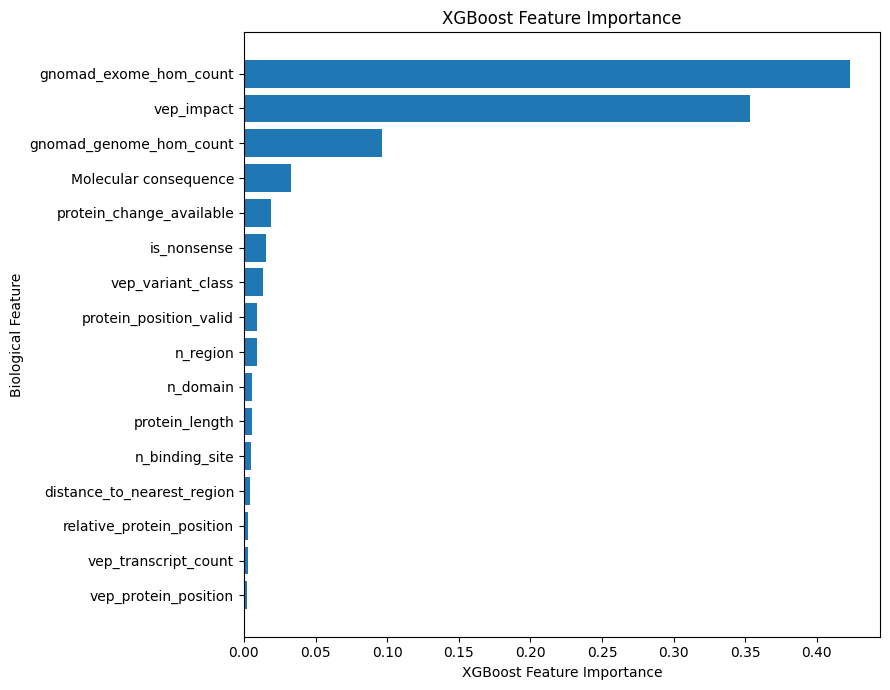

In [34]:
plt.figure(figsize=(9, 7))

plot_df = xgb_importance.sort_values(
    "importance"
)

plt.barh(
    plot_df["feature"],
    plot_df["importance"]
)

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Biological Feature")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

In [35]:
from sklearn.neural_network import MLPClassifier

print("MLP imported successfully.")

MLP imported successfully.


In [36]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=RANDOM_STATE
)

print(mlp_model)

MLPClassifier(batch_size=256, early_stopping=True, hidden_layer_sizes=(64, 32),
              max_iter=100, random_state=42)


In [37]:
print("=" * 70)
print("TRAINING MLP")
print("=" * 70)

mlp_model.fit(
    X_train,
    y_train
)

print("\nMLP training complete.")
print(f"Iterations: {mlp_model.n_iter_}")

TRAINING MLP

MLP training complete.
Iterations: 71


In [38]:
mlp_val_metrics = evaluate_model(
    mlp_model,
    X_val,
    y_val,
    model_name="MLP Neural Network"
)

MLP Neural Network
Accuracy            : 0.9002
Balanced Accuracy   : 0.8801
Precision           : 0.9216
Recall              : 0.9339
F1                  : 0.9277
ROC-AUC             : 0.9649
PR-AUC              : 0.9841
MCC                 : 0.7665

Confusion Matrix:
[[ 4556   957]
 [  797 11257]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8511    0.8264    0.8386      5513
           1     0.9216    0.9339    0.9277     12054

    accuracy                         0.9002     17567
   macro avg     0.8864    0.8801    0.8832     17567
weighted avg     0.8995    0.9002    0.8997     17567



In [39]:
results.append(mlp_val_metrics)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
0,Random Forest,0.965390,0.956226,0.969098,0.980836,0.974932,0.992917,0.995798,0.919230
1,XGBoost,0.955769,0.951332,0.972039,0.963249,0.967624,0.991716,0.995993,0.897940
2,MLP Neural Network,0.900154,0.880146,0.921647,0.933881,0.927724,0.964935,0.984140,0.766500
3,Logistic Regression,0.816588,0.860298,0.986451,0.742907,0.847530,0.931872,0.969847,0.669157


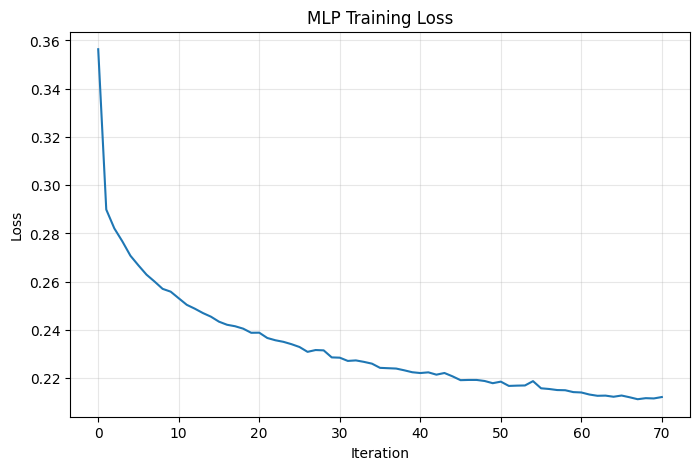

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    mlp_model.loss_curve_
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP Training Loss")

plt.grid(alpha=0.3)
plt.show()

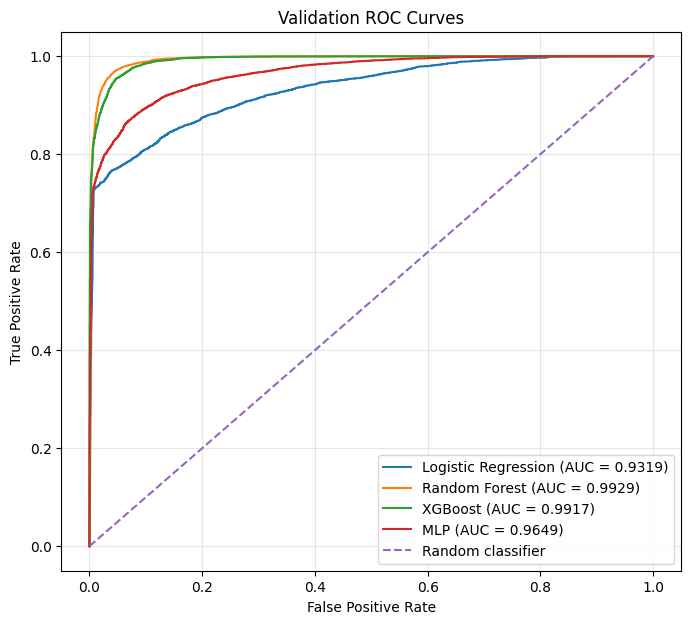

In [41]:
lr_prob = logistic_model.predict_proba(X_val)[:, 1]
rf_prob = rf_model.predict_proba(X_val)[:, 1]
xgb_prob = xgb_model.predict_proba(X_val)[:, 1]
mlp_prob = mlp_model.predict_proba(X_val)[:, 1]

models_prob = {
    "Logistic Regression": lr_prob,
    "Random Forest": rf_prob,
    "XGBoost": xgb_prob,
    "MLP": mlp_prob
}

plt.figure(figsize=(8, 7))

for name, probabilities in models_prob.items():
    
    fpr, tpr, _ = roc_curve(
        y_val,
        probabilities
    )
    
    auc = roc_auc_score(
        y_val,
        probabilities
    )
    
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

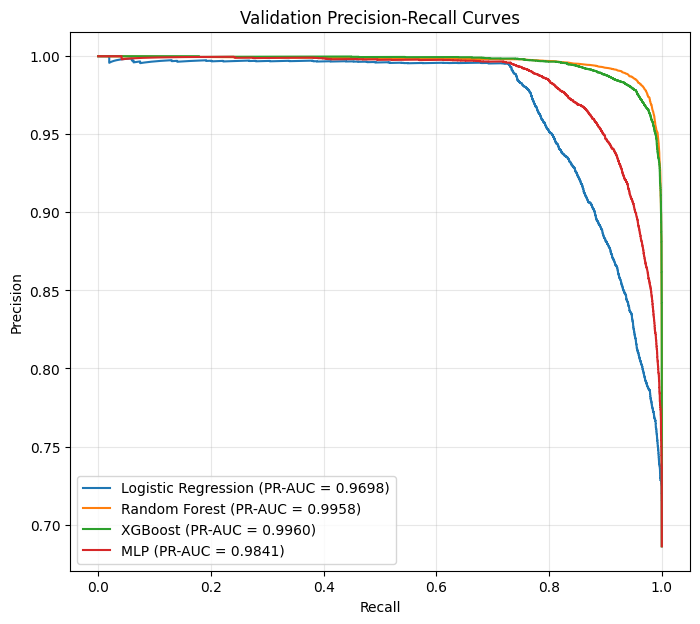

In [42]:
plt.figure(figsize=(8, 7))

for name, probabilities in models_prob.items():
    
    precision, recall, _ = precision_recall_curve(
        y_val,
        probabilities
    )
    
    ap = average_precision_score(
        y_val,
        probabilities
    )
    
    plt.plot(
        recall,
        precision,
        label=f"{name} (PR-AUC = {ap:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curves")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [45]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.5.1+cu121
CUDA available: True
Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [46]:
X_train_tensor = torch.tensor(
    X_train.values,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

X_val_tensor = torch.tensor(
    X_val.values,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
).reshape(-1, 1)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("X_val:", X_val_tensor.shape)
print("y_val:", y_val_tensor.shape)

X_train: torch.Size([81977, 16])
y_train: torch.Size([81977, 1])
X_val: torch.Size([17567, 16])
y_val: torch.Size([17567, 1])


In [47]:
BATCH_SIZE = 256

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 321
Validation batches: 69


In [48]:
class BiologicalMLP(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [49]:
input_dim = X_train.shape[1]

model = BiologicalMLP(input_dim).to(device)

print(model)

BiologicalMLP(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [50]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print("Optimizer:", optimizer)
print("Initial learning rate:", optimizer.param_groups[0]["lr"])

Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Initial learning rate: 0.001


In [51]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss = 0.0
    total_samples = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(X_batch)

        loss = criterion(logits, y_batch)

        loss.backward()

        optimizer.step()

        batch_size = X_batch.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples

In [52]:
@torch.no_grad()
def evaluate_pytorch(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_probs = []
    all_targets = []

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        logits = model(X_batch)

        loss = criterion(logits, y_batch)

        probs = torch.sigmoid(logits)

        batch_size = X_batch.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_probs.append(probs.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

    avg_loss = total_loss / total_samples

    y_true = np.concatenate(all_targets).ravel()
    y_prob = np.concatenate(all_probs).ravel()

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    return avg_loss, roc_auc, pr_auc, y_true, y_prob

In [53]:
NUM_EPOCHS = 50
PATIENCE = 8

best_val_auc = -np.inf
best_state = None
epochs_without_improvement = 0

history = []

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_roc_auc, val_pr_auc, _, _ = evaluate_pytorch(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_roc_auc)

    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_roc_auc": val_roc_auc,
        "val_pr_auc": val_pr_auc,
        "learning_rate": current_lr
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"ROC-AUC: {val_roc_auc:.4f} | "
        f"PR-AUC: {val_pr_auc:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    if val_roc_auc > best_val_auc:

        best_val_auc = val_roc_auc

        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:

            print("\nEarly stopping triggered.")

            break

Epoch 01 | Train Loss: 0.3510 | Val Loss: 0.2920 | ROC-AUC: 0.9312 | PR-AUC: 0.9688 | LR: 1.00e-03
Epoch 02 | Train Loss: 0.2933 | Val Loss: 0.2790 | ROC-AUC: 0.9385 | PR-AUC: 0.9729 | LR: 1.00e-03
Epoch 03 | Train Loss: 0.2863 | Val Loss: 0.2755 | ROC-AUC: 0.9409 | PR-AUC: 0.9736 | LR: 1.00e-03
Epoch 04 | Train Loss: 0.2794 | Val Loss: 0.2687 | ROC-AUC: 0.9450 | PR-AUC: 0.9755 | LR: 1.00e-03
Epoch 05 | Train Loss: 0.2741 | Val Loss: 0.2638 | ROC-AUC: 0.9468 | PR-AUC: 0.9763 | LR: 1.00e-03
Epoch 06 | Train Loss: 0.2705 | Val Loss: 0.2615 | ROC-AUC: 0.9484 | PR-AUC: 0.9768 | LR: 1.00e-03
Epoch 07 | Train Loss: 0.2666 | Val Loss: 0.2583 | ROC-AUC: 0.9497 | PR-AUC: 0.9772 | LR: 1.00e-03
Epoch 08 | Train Loss: 0.2643 | Val Loss: 0.2567 | ROC-AUC: 0.9508 | PR-AUC: 0.9778 | LR: 1.00e-03
Epoch 09 | Train Loss: 0.2597 | Val Loss: 0.2509 | ROC-AUC: 0.9532 | PR-AUC: 0.9785 | LR: 1.00e-03
Epoch 10 | Train Loss: 0.2576 | Val Loss: 0.2492 | ROC-AUC: 0.9539 | PR-AUC: 0.9791 | LR: 1.00e-03
Epoch 11 |

In [56]:
# Get validation predictions from the best checkpoint
val_loss, val_roc_auc, val_pr_auc, y_val_true, y_val_prob = evaluate_pytorch(
    model,
    val_loader,
    criterion,
    device
)

# Convert probabilities to class predictions
y_val_pred = (y_val_prob >= 0.5).astype(int)

# Calculate metrics
metrics_pytorch = {
    "Accuracy": accuracy_score(y_val_true, y_val_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_val_true, y_val_pred),
    "Precision": precision_score(y_val_true, y_val_pred),
    "Recall": recall_score(y_val_true, y_val_pred),
    "F1": f1_score(y_val_true, y_val_pred),
    "ROC-AUC": roc_auc_score(y_val_true, y_val_prob),
    "PR-AUC": average_precision_score(y_val_true, y_val_prob),
    "MCC": matthews_corrcoef(y_val_true, y_val_pred)
}

print("=" * 60)
print("PYTORCH MLP — VALIDATION RESULTS")
print("=" * 60)

for metric, value in metrics_pytorch.items():
    print(f"{metric:<20}: {value:.6f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_true, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val_true, y_val_pred))

history_df = pd.DataFrame(history)

best_epoch = history_df.loc[
    history_df["val_roc_auc"].idxmax()
]

print("Best epoch:")
print(best_epoch)

print("\nLast epoch:")
print(history_df.iloc[-1])

PYTORCH MLP — VALIDATION RESULTS
Accuracy            : 0.911880
Balanced Accuracy   : 0.898681
Precision           : 0.937240
Recall              : 0.934130
F1                  : 0.935682
ROC-AUC             : 0.972242
PR-AUC              : 0.987016
MCC                 : 0.795807

Confusion Matrix:
[[ 4759   754]
 [  794 11260]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.86      0.86      5513
         1.0       0.94      0.93      0.94     12054

    accuracy                           0.91     17567
   macro avg       0.90      0.90      0.90     17567
weighted avg       0.91      0.91      0.91     17567

Best epoch:
epoch            49.000000
train_loss        0.205131
val_loss          0.196530
val_roc_auc       0.972242
val_pr_auc        0.987016
learning_rate     0.000500
Name: 48, dtype: float64

Last epoch:
epoch            50.000000
train_loss        0.204918
val_loss          0.196450
val_roc_auc       0.97219

In [57]:
class ConfigurableMLP(nn.Module):

    def __init__(self, input_dim, hidden_layers=(128, 64, 32), dropout=0.2):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [58]:
def train_mlp(
    hidden_layers=(128, 64, 32),
    dropout=0.2,
    learning_rate=1e-3,
    weight_decay=1e-4,
    max_epochs=80,
    patience=10
):

    model = ConfigurableMLP(
        input_dim=X_train.shape[1],
        hidden_layers=hidden_layers,
        dropout=dropout
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=4
    )

    best_auc = -np.inf
    best_state = None
    epochs_without_improvement = 0

    history = []

    for epoch in range(1, max_epochs + 1):

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_auc, val_pr, _, _ = evaluate_pytorch(
            model,
            val_loader,
            criterion,
            device
        )

        scheduler.step(val_auc)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_roc_auc": val_auc,
            "val_pr_auc": val_pr,
            "learning_rate": optimizer.param_groups[0]["lr"]
        })

        if val_auc > best_auc:
            best_auc = val_auc

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    return model, history_df, best_auc

In [59]:
mlp_configs = [
    {
        "name": "MLP_128_64_32",
        "hidden_layers": (128, 64, 32),
        "dropout": 0.20
    },
    {
        "name": "MLP_256_128_64",
        "hidden_layers": (256, 128, 64),
        "dropout": 0.20
    },
    {
        "name": "MLP_128_64",
        "hidden_layers": (128, 64),
        "dropout": 0.10
    },
    {
        "name": "MLP_256_128_64_32",
        "hidden_layers": (256, 128, 64, 32),
        "dropout": 0.10
    }
]

pd.DataFrame(mlp_configs)

,name,hidden_layers,dropout
0,MLP_128_64_32,"(128, 64, 32)",0.2
1,MLP_256_128_64,"(256, 128, 64)",0.2
2,MLP_128_64,"(128, 64)",0.1
3,MLP_256_128_64_32,"(256, 128, 64, 32)",0.1


In [60]:
mlp_results = []
trained_models = {}
training_histories = {}

for config in mlp_configs:

    print("=" * 70)
    print(f"Training: {config['name']}")
    print("=" * 70)

    model_i, history_i, best_auc_i = train_mlp(
        hidden_layers=config["hidden_layers"],
        dropout=config["dropout"],
        learning_rate=1e-3,
        weight_decay=1e-4,
        max_epochs=80,
        patience=10
    )

    _, _, _, y_true_i, y_prob_i = evaluate_pytorch(
        model_i,
        val_loader,
        nn.BCEWithLogitsLoss(),
        device
    )

    y_pred_i = (y_prob_i >= 0.5).astype(int)

    result = {
        "Model": config["name"],
        "Architecture": str(config["hidden_layers"]),
        "Dropout": config["dropout"],
        "Best ROC-AUC": roc_auc_score(y_true_i, y_prob_i),
        "PR-AUC": average_precision_score(y_true_i, y_prob_i),
        "Accuracy": accuracy_score(y_true_i, y_pred_i),
        "Balanced Accuracy": balanced_accuracy_score(y_true_i, y_pred_i),
        "Precision": precision_score(y_true_i, y_pred_i),
        "Recall": recall_score(y_true_i, y_pred_i),
        "F1": f1_score(y_true_i, y_pred_i),
        "MCC": matthews_corrcoef(y_true_i, y_pred_i),
        "Best Epoch": history_i.loc[
            history_i["val_roc_auc"].idxmax(), "epoch"
        ]
    }

    mlp_results.append(result)

    trained_models[config["name"]] = model_i
    training_histories[config["name"]] = history_i

    print(
        f"ROC-AUC: {result['Best ROC-AUC']:.4f} | "
        f"PR-AUC: {result['PR-AUC']:.4f} | "
        f"F1: {result['F1']:.4f} | "
        f"MCC: {result['MCC']:.4f}"
    )

mlp_results_df = pd.DataFrame(mlp_results)

print("\n" + "=" * 70)
print("MLP ARCHITECTURE RESULTS")
print("=" * 70)

display(
    mlp_results_df.sort_values(
        "Best ROC-AUC",
        ascending=False
    )
)

Training: MLP_128_64_32
ROC-AUC: 0.9758 | PR-AUC: 0.9888 | F1: 0.9435 | MCC: 0.8155
Training: MLP_256_128_64
ROC-AUC: 0.9774 | PR-AUC: 0.9895 | F1: 0.9452 | MCC: 0.8229
Training: MLP_128_64
ROC-AUC: 0.9742 | PR-AUC: 0.9880 | F1: 0.9410 | MCC: 0.8067
Training: MLP_256_128_64_32
ROC-AUC: 0.9780 | PR-AUC: 0.9897 | F1: 0.9468 | MCC: 0.8275

MLP ARCHITECTURE RESULTS


,Model,Architecture,Dropout,Best ROC-AUC,PR-AUC,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,Best Epoch
3,MLP_256_128_64_32,"(256, 128, 64, 32)",0.1,0.977977,0.989659,0.926339,0.909365,0.938754,0.954953,0.946784,0.827516,78
1,MLP_256_128_64,"(256, 128, 64)",0.2,0.977377,0.989468,0.924290,0.907822,0.938502,0.952049,0.945227,0.822911,75
0,MLP_128_64_32,"(128, 64, 32)",0.2,0.975794,0.988767,0.921444,0.901417,0.932006,0.955202,0.943461,0.815526,78
2,MLP_128_64,"(128, 64)",0.1,0.974229,0.987955,0.917800,0.896006,0.927754,0.954538,0.940955,0.806698,77


In [61]:
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Random seed fixed at:", SEED)

Random seed fixed at: 42


In [62]:
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    generator=g,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    pin_memory=True
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 321
Validation batches: 69


In [63]:
final_mlp, final_history, final_best_auc = train_mlp(
    hidden_layers=(256, 128, 64, 32),
    dropout=0.10,
    learning_rate=1e-3,
    weight_decay=1e-4,
    max_epochs=120,
    patience=12
)

print("\n" + "=" * 70)
print("FINAL PYTORCH MLP TRAINING COMPLETE")
print("=" * 70)

print(f"Best validation ROC-AUC: {final_best_auc:.6f}")

best_row = final_history.loc[
    final_history["val_roc_auc"].idxmax()
]

print(f"Best epoch: {int(best_row['epoch'])}")
print(f"Best PR-AUC: {best_row['val_pr_auc']:.6f}")


FINAL PYTORCH MLP TRAINING COMPLETE
Best validation ROC-AUC: 0.979283
Best epoch: 118
Best PR-AUC: 0.990205


In [64]:
final_criterion = nn.BCEWithLogitsLoss()

_, _, _, y_val_true_final, y_val_prob_final = evaluate_pytorch(
    final_mlp,
    val_loader,
    final_criterion,
    device
)

y_val_pred_final = (
    y_val_prob_final >= 0.5
).astype(int)

final_mlp_metrics = {
    "Accuracy": accuracy_score(
        y_val_true_final,
        y_val_pred_final
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_val_true_final,
        y_val_pred_final
    ),
    "Precision": precision_score(
        y_val_true_final,
        y_val_pred_final
    ),
    "Recall": recall_score(
        y_val_true_final,
        y_val_pred_final
    ),
    "F1": f1_score(
        y_val_true_final,
        y_val_pred_final
    ),
    "ROC-AUC": roc_auc_score(
        y_val_true_final,
        y_val_prob_final
    ),
    "PR-AUC": average_precision_score(
        y_val_true_final,
        y_val_prob_final
    ),
    "MCC": matthews_corrcoef(
        y_val_true_final,
        y_val_pred_final
    )
}

print("=" * 60)
print("FINAL PYTORCH MLP — VALIDATION RESULTS")
print("=" * 60)

for metric, value in final_mlp_metrics.items():
    print(f"{metric:<20}: {value:.6f}")

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_val_true_final,
    y_val_pred_final
))

print("\nClassification Report:")
print(classification_report(
    y_val_true_final,
    y_val_pred_final
))

FINAL PYTORCH MLP — VALIDATION RESULTS
Accuracy            : 0.929812
Balanced Accuracy   : 0.914405
Precision           : 0.942722
Recall              : 0.955782
F1                  : 0.949207
ROC-AUC             : 0.979283
PR-AUC              : 0.990205
MCC                 : 0.835885

Confusion Matrix:
[[ 4813   700]
 [  533 11521]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.87      0.89      5513
         1.0       0.94      0.96      0.95     12054

    accuracy                           0.93     17567
   macro avg       0.92      0.91      0.92     17567
weighted avg       0.93      0.93      0.93     17567



In [65]:
final_leaderboard = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Features": 16,
        "ROC-AUC": 0.992917,
        "PR-AUC": 0.995798,
        "F1": 0.974932,
        "MCC": 0.919230
    },
    {
        "Model": "XGBoost",
        "Features": 16,
        "ROC-AUC": 0.991716,
        "PR-AUC": 0.995993,
        "F1": 0.967624,
        "MCC": 0.897940
    },
    {
        "Model": "PyTorch MLP",
        "Features": 16,
        "ROC-AUC": final_mlp_metrics["ROC-AUC"],
        "PR-AUC": final_mlp_metrics["PR-AUC"],
        "F1": final_mlp_metrics["F1"],
        "MCC": final_mlp_metrics["MCC"]
    },
    {
        "Model": "Logistic Regression",
        "Features": 16,
        "ROC-AUC": 0.931872,
        "PR-AUC": 0.969847,
        "F1": 0.847530,
        "MCC": 0.669157
    }
])

final_leaderboard = final_leaderboard.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(final_leaderboard)

,Model,Features,ROC-AUC,PR-AUC,F1,MCC
0,Random Forest,16,0.992917,0.995798,0.974932,0.919230
1,XGBoost,16,0.991716,0.995993,0.967624,0.897940
2,PyTorch MLP,16,0.979283,0.990205,0.949207,0.835885
3,Logistic Regression,16,0.931872,0.969847,0.847530,0.669157


In [66]:
qnn_features = [
    "gnomad_exome_hom_count",
    "vep_impact",
    "gnomad_genome_hom_count",
    "Molecular consequence"
]

print("Selected features for 4-feature benchmark:")
for i, feature in enumerate(qnn_features, 1):
    print(f"{i}. {feature}")

# Verify that all features exist
for feature in qnn_features:
    assert feature in X_train.columns, f"Missing feature: {feature}"

print("\nAll 4 features found.")

Selected features for 4-feature benchmark:
1. gnomad_exome_hom_count
2. vep_impact
3. gnomad_genome_hom_count
4. Molecular consequence

All 4 features found.


In [67]:
X_train_4 = X_train[qnn_features].copy()
X_val_4 = X_val[qnn_features].copy()
X_test_4 = X_test[qnn_features].copy()

print("X_train_4:", X_train_4.shape)
print("X_val_4:  ", X_val_4.shape)
print("X_test_4: ", X_test_4.shape)

X_train_4: (81977, 4)
X_val_4:   (17567, 4)
X_test_4:  (17567, 4)


In [68]:
display(X_train_4.describe().T)

,count,mean,std,min,25%,50%,75%,max
gnomad_exome_hom_count,81977.0,6.659889e-17,1.000006,-0.111496,-0.111496,-0.111496,-0.111496,15.707419
vep_impact,81977.0,5.007136e-01,0.500003,0.000000,0.000000,1.000000,1.000000,1.000000
gnomad_genome_hom_count,81977.0,3.283661e-17,1.000006,-0.114978,-0.114978,-0.114978,-0.114978,15.795847
Molecular consequence,81977.0,3.911341e-01,0.488007,0.000000,0.000000,0.000000,1.000000,1.000000


In [69]:
print("Training missing values:")
print(X_train_4.isna().sum())

print("\nValidation missing values:")
print(X_val_4.isna().sum())

print("\nTest missing values:")
print(X_test_4.isna().sum())

print("\nInfinite values:")
print("Train:", np.isinf(X_train_4.values).sum())
print("Val:  ", np.isinf(X_val_4.values).sum())
print("Test: ", np.isinf(X_test_4.values).sum())

Training missing values:
gnomad_exome_hom_count     0
vep_impact                 0
gnomad_genome_hom_count    0
Molecular consequence      0
dtype: int64

Validation missing values:
gnomad_exome_hom_count     0
vep_impact                 0
gnomad_genome_hom_count    0
Molecular consequence      0
dtype: int64

Test missing values:
gnomad_exome_hom_count     0
vep_impact                 0
gnomad_genome_hom_count    0
Molecular consequence      0
dtype: int64

Infinite values:
Train: 0
Val:   0
Test:  0


In [70]:
from sklearn.linear_model import LogisticRegression

lr_4 = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_4.fit(X_train_4, y_train)

lr_4_results = evaluate_model(
    lr_4,
    X_val_4,
    y_val,
    "Logistic Regression — 4 Features"
)

Logistic Regression — 4 Features
Accuracy            : 0.8107
Balanced Accuracy   : 0.8602
Precision           : 0.9956
Recall              : 0.7274
F1                  : 0.8406
ROC-AUC             : 0.9424
PR-AUC              : 0.9668
MCC                 : 0.6685

Confusion Matrix:
[[5474   39]
 [3286 8768]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6249    0.9929    0.7670      5513
           1     0.9956    0.7274    0.8406     12054

    accuracy                         0.8107     17567
   macro avg     0.8102    0.8602    0.8038     17567
weighted avg     0.8792    0.8107    0.8175     17567



In [71]:
rf_4 = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_4.fit(X_train_4, y_train)

rf_4_results = evaluate_model(
    rf_4,
    X_val_4,
    y_val,
    "Random Forest — 4 Features"
)

Random Forest — 4 Features
Accuracy            : 0.8973
Balanced Accuracy   : 0.8716
Precision           : 0.9124
Recall              : 0.9407
F1                  : 0.9263
ROC-AUC             : 0.9636
PR-AUC              : 0.9736
MCC                 : 0.7580

Confusion Matrix:
[[ 4424  1089]
 [  715 11339]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8609    0.8025    0.8306      5513
           1     0.9124    0.9407    0.9263     12054

    accuracy                         0.8973     17567
   macro avg     0.8866    0.8716    0.8785     17567
weighted avg     0.8962    0.8973    0.8963     17567



In [72]:
from xgboost import XGBClassifier

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight_4 = negative_count / positive_count

xgb_4 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight_4,
    random_state=42,
    n_jobs=-1
)

xgb_4.fit(X_train_4, y_train)

xgb_4_results = evaluate_model(
    xgb_4,
    X_val_4,
    y_val,
    "XGBoost — 4 Features"
)

XGBoost — 4 Features
Accuracy            : 0.8973
Balanced Accuracy   : 0.8716
Precision           : 0.9124
Recall              : 0.9407
F1                  : 0.9263
ROC-AUC             : 0.9636
PR-AUC              : 0.9736
MCC                 : 0.7580

Confusion Matrix:
[[ 4424  1089]
 [  715 11339]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8609    0.8025    0.8306      5513
           1     0.9124    0.9407    0.9263     12054

    accuracy                         0.8973     17567
   macro avg     0.8866    0.8716    0.8785     17567
weighted avg     0.8962    0.8973    0.8963     17567



In [153]:
X_train_4_tensor = torch.tensor(
    X_train_4.values,
    dtype=torch.float32
)

X_val_4_tensor = torch.tensor(
    X_val_4.values,
    dtype=torch.float32
)

y_train_4_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

y_val_4_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
).reshape(-1, 1)

print("X_train_4:", X_train_4_tensor.shape)
print("X_val_4:", X_val_4_tensor.shape)

X_train_4: torch.Size([81977, 4])
X_val_4: torch.Size([17567, 4])


In [154]:
train_dataset_4 = TensorDataset(
    X_train_4_tensor,
    y_train_4_tensor
)

val_dataset_4 = TensorDataset(
    X_val_4_tensor,
    y_val_4_tensor
)

g4 = torch.Generator()
g4.manual_seed(42)

train_loader_4 = DataLoader(
    train_dataset_4,
    batch_size=256,
    shuffle=True,
    generator=g4,
    pin_memory=True
)

val_loader_4 = DataLoader(
    val_dataset_4,
    batch_size=256,
    shuffle=False,
    pin_memory=True
)

print("Training batches:", len(train_loader_4))
print("Validation batches:", len(val_loader_4))

Training batches: 321
Validation batches: 69


In [155]:
class MLP4(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

In [156]:
model_4 = MLP4().to(device)

criterion_4 = nn.BCEWithLogitsLoss()

optimizer_4 = torch.optim.AdamW(
    model_4.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler_4 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_4,
    mode="max",
    factor=0.5,
    patience=4
)

best_auc_4 = -np.inf
best_state_4 = None
epochs_without_improvement_4 = 0

history_4 = []

MAX_EPOCHS_4 = 100
PATIENCE_4 = 12

for epoch in range(1, MAX_EPOCHS_4 + 1):

    model_4.train()

    total_loss = 0.0
    total_samples = 0

    for X_batch, y_batch in train_loader_4:

        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer_4.zero_grad()

        logits = model_4(X_batch)

        loss = criterion_4(logits, y_batch)

        loss.backward()

        optimizer_4.step()

        batch_size = X_batch.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    train_loss = total_loss / total_samples

    # Validation
    model_4.eval()

    val_probs = []
    val_targets = []
    val_loss_total = 0.0
    val_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader_4:

            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            logits = model_4(X_batch)

            loss = criterion_4(logits, y_batch)

            probs = torch.sigmoid(logits)

            batch_size = X_batch.size(0)

            val_loss_total += loss.item() * batch_size
            val_samples += batch_size

            val_probs.append(probs.cpu().numpy())
            val_targets.append(y_batch.cpu().numpy())

    val_loss = val_loss_total / val_samples

    y_true_4 = np.concatenate(val_targets).ravel()
    y_prob_4 = np.concatenate(val_probs).ravel()

    val_auc_4 = roc_auc_score(y_true_4, y_prob_4)
    val_pr_4 = average_precision_score(y_true_4, y_prob_4)

    scheduler_4.step(val_auc_4)

    current_lr = optimizer_4.param_groups[0]["lr"]

    history_4.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_roc_auc": val_auc_4,
        "val_pr_auc": val_pr_4,
        "learning_rate": current_lr
    })

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"ROC-AUC: {val_auc_4:.4f} | "
            f"PR-AUC: {val_pr_4:.4f}"
        )

    if val_auc_4 > best_auc_4:

        best_auc_4 = val_auc_4

        best_state_4 = {
            k: v.detach().cpu().clone()
            for k, v in model_4.state_dict().items()
        }

        epochs_without_improvement_4 = 0

    else:

        epochs_without_improvement_4 += 1

        if epochs_without_improvement_4 >= PATIENCE_4:

            print(f"\nEarly stopping at epoch {epoch}.")
            break

model_4.load_state_dict(best_state_4)

print("\nBest 4-feature MLP ROC-AUC:", best_auc_4)

Epoch 001 | Train Loss: 0.3796 | Val Loss: 0.3157 | ROC-AUC: 0.9118 | PR-AUC: 0.9614
Epoch 010 | Train Loss: 0.2887 | Val Loss: 0.2801 | ROC-AUC: 0.9409 | PR-AUC: 0.9731
Epoch 020 | Train Loss: 0.2568 | Val Loss: 0.2417 | ROC-AUC: 0.9556 | PR-AUC: 0.9788
Epoch 030 | Train Loss: 0.2408 | Val Loss: 0.2265 | ROC-AUC: 0.9606 | PR-AUC: 0.9808
Epoch 040 | Train Loss: 0.2328 | Val Loss: 0.2182 | ROC-AUC: 0.9644 | PR-AUC: 0.9824
Epoch 050 | Train Loss: 0.2262 | Val Loss: 0.2315 | ROC-AUC: 0.9669 | PR-AUC: 0.9835
Epoch 060 | Train Loss: 0.2209 | Val Loss: 0.2106 | ROC-AUC: 0.9673 | PR-AUC: 0.9837
Epoch 070 | Train Loss: 0.2125 | Val Loss: 0.2039 | ROC-AUC: 0.9694 | PR-AUC: 0.9850
Epoch 080 | Train Loss: 0.2106 | Val Loss: 0.2003 | ROC-AUC: 0.9694 | PR-AUC: 0.9850
Epoch 090 | Train Loss: 0.2082 | Val Loss: 0.2004 | ROC-AUC: 0.9679 | PR-AUC: 0.9845
Epoch 100 | Train Loss: 0.2039 | Val Loss: 0.1967 | ROC-AUC: 0.9697 | PR-AUC: 0.9852

Best 4-feature MLP ROC-AUC: 0.9705564785540466


In [158]:
model_4.eval()

with torch.no_grad():

    X_val_gpu_4 = X_val_4_tensor.to(device)

    logits_4 = model_4(X_val_gpu_4)

    y_prob_mlp4 = torch.sigmoid(logits_4).cpu().numpy().ravel()

y_pred_mlp4 = (y_prob_mlp4 >= 0.5).astype(int)

mlp_4_metrics = {
    "Accuracy": accuracy_score(y_val, y_pred_mlp4),
    "Balanced Accuracy": balanced_accuracy_score(y_val, y_pred_mlp4),
    "Precision": precision_score(y_val, y_pred_mlp4),
    "Recall": recall_score(y_val, y_pred_mlp4),
    "F1": f1_score(y_val, y_pred_mlp4),
    "ROC-AUC": roc_auc_score(y_val, y_prob_mlp4),
    "PR-AUC": average_precision_score(y_val, y_prob_mlp4),
    "MCC": matthews_corrcoef(y_val, y_pred_mlp4)
}

print("=" * 60)
print("PYTORCH MLP — 4 FEATURES")
print("=" * 60)

for metric, value in mlp_4_metrics.items():
    print(f"{metric:<20}: {value:.6f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_mlp4))

PYTORCH MLP — 4 FEATURES
Accuracy            : 0.904480
Balanced Accuracy   : 0.881280
Precision           : 0.919334
Recall              : 0.943587
F1                  : 0.931303
ROC-AUC             : 0.970556
PR-AUC              : 0.985502
MCC                 : 0.775392

Confusion Matrix:
[[ 4515   998]
 [  680 11374]]


In [78]:
four_feature_leaderboard = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Features": 4,
        "ROC-AUC": lr_4_results["ROC-AUC"],
        "PR-AUC": lr_4_results["PR-AUC"],
        "F1": lr_4_results["F1"],
        "MCC": lr_4_results["MCC"]
    },
    {
        "Model": "Random Forest",
        "Features": 4,
        "ROC-AUC": rf_4_results["ROC-AUC"],
        "PR-AUC": rf_4_results["PR-AUC"],
        "F1": rf_4_results["F1"],
        "MCC": rf_4_results["MCC"]
    },
    {
        "Model": "XGBoost",
        "Features": 4,
        "ROC-AUC": xgb_4_results["ROC-AUC"],
        "PR-AUC": xgb_4_results["PR-AUC"],
        "F1": xgb_4_results["F1"],
        "MCC": xgb_4_results["MCC"]
    },
    {
        "Model": "PyTorch MLP",
        "Features": 4,
        "ROC-AUC": mlp_4_metrics["ROC-AUC"],
        "PR-AUC": mlp_4_metrics["PR-AUC"],
        "F1": mlp_4_metrics["F1"],
        "MCC": mlp_4_metrics["MCC"]
    }
])

four_feature_leaderboard = (
    four_feature_leaderboard
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(four_feature_leaderboard)

,Model,Features,ROC-AUC,PR-AUC,F1,MCC
0,XGBoost,4,0.963609,0.973632,0.926313,0.758048
1,Random Forest,4,0.963576,0.973593,0.926313,0.758048
2,PyTorch MLP,4,0.962714,0.973282,0.937146,0.788715
3,Logistic Regression,4,0.942371,0.966807,0.840612,0.668526


In [79]:
from sklearn.feature_selection import mutual_info_classif

print("=" * 70)
print("RANKING FEATURES USING TRAINING DATA ONLY")
print("=" * 70)

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_ranking = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "MI_Score": mi_scores
    })
    .sort_values("MI_Score", ascending=False)
    .reset_index(drop=True)
)

display(mi_ranking)

RANKING FEATURES USING TRAINING DATA ONLY


,Feature,MI_Score
0,gnomad_exome_hom_count,0.337066
1,vep_impact,0.286758
2,gnomad_genome_hom_count,0.267565
3,protein_length,0.188249
4,Molecular consequence,0.143545
5,vep_variant_class,0.096355
6,is_nonsense,0.076366
7,relative_protein_position,0.066889
8,vep_protein_position,0.052848
9,protein_change_available,0.046228


In [80]:
feature_counts = [2, 4, 6, 8, 10, 12, 16]

feature_sets = {}

for k in feature_counts:
    feature_sets[k] = mi_ranking["Feature"].iloc[:k].tolist()

print("=" * 70)
print("FEATURE SETS")
print("=" * 70)

for k, features in feature_sets.items():
    print(f"\nTop {k} features:")
    for feature in features:
        print(f"  - {feature}")

FEATURE SETS

Top 2 features:
  - gnomad_exome_hom_count
  - vep_impact

Top 4 features:
  - gnomad_exome_hom_count
  - vep_impact
  - gnomad_genome_hom_count
  - protein_length

Top 6 features:
  - gnomad_exome_hom_count
  - vep_impact
  - gnomad_genome_hom_count
  - protein_length
  - Molecular consequence
  - vep_variant_class

Top 8 features:
  - gnomad_exome_hom_count
  - vep_impact
  - gnomad_genome_hom_count
  - protein_length
  - Molecular consequence
  - vep_variant_class
  - is_nonsense
  - relative_protein_position

Top 10 features:
  - gnomad_exome_hom_count
  - vep_impact
  - gnomad_genome_hom_count
  - protein_length
  - Molecular consequence
  - vep_variant_class
  - is_nonsense
  - relative_protein_position
  - vep_protein_position
  - protein_change_available

Top 12 features:
  - gnomad_exome_hom_count
  - vep_impact
  - gnomad_genome_hom_count
  - protein_length
  - Molecular consequence
  - vep_variant_class
  - is_nonsense
  - relative_protein_position
  - vep_prot

In [81]:
topk_rf_results = []

for k in feature_counts:

    features = feature_sets[k]

    print(f"\nTraining Random Forest with top {k} features...")

    rf_k = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf_k.fit(
        X_train[features],
        y_train
    )

    y_prob = rf_k.predict_proba(
        X_val[features]
    )[:, 1]

    y_pred = (y_prob >= 0.5).astype(int)

    topk_rf_results.append({
        "Features": k,
        "ROC-AUC": roc_auc_score(y_val, y_prob),
        "PR-AUC": average_precision_score(y_val, y_prob),
        "F1": f1_score(y_val, y_pred),
        "MCC": matthews_corrcoef(y_val, y_pred)
    })

topk_rf_df = pd.DataFrame(topk_rf_results)

display(topk_rf_df)


Training Random Forest with top 2 features...

Training Random Forest with top 4 features...

Training Random Forest with top 6 features...

Training Random Forest with top 8 features...

Training Random Forest with top 10 features...

Training Random Forest with top 12 features...

Training Random Forest with top 16 features...


,Features,ROC-AUC,PR-AUC,F1,MCC
0,2,0.960379,0.968263,0.841156,0.671415
1,4,0.985456,0.990975,0.963191,0.884077
2,6,0.984767,0.990093,0.963241,0.884172
3,8,0.988274,0.993602,0.965616,0.888514
4,10,0.986731,0.992728,0.963541,0.881664
5,12,0.990688,0.994629,0.970891,0.905628
6,16,0.993056,0.995960,0.975137,0.919897


In [82]:
topk_xgb_results = []

for k in feature_counts:

    features = feature_sets[k]

    print(f"\nTraining XGBoost with top {k} features...")

    xgb_k = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight_4,
        random_state=42,
        n_jobs=-1
    )

    xgb_k.fit(
        X_train[features],
        y_train
    )

    y_prob = xgb_k.predict_proba(
        X_val[features]
    )[:, 1]

    y_pred = (y_prob >= 0.5).astype(int)

    topk_xgb_results.append({
        "Features": k,
        "ROC-AUC": roc_auc_score(y_val, y_prob),
        "PR-AUC": average_precision_score(y_val, y_prob),
        "F1": f1_score(y_val, y_pred),
        "MCC": matthews_corrcoef(y_val, y_pred)
    })

topk_xgb_df = pd.DataFrame(topk_xgb_results)

display(topk_xgb_df)


Training XGBoost with top 2 features...

Training XGBoost with top 4 features...

Training XGBoost with top 6 features...

Training XGBoost with top 8 features...

Training XGBoost with top 10 features...

Training XGBoost with top 12 features...

Training XGBoost with top 16 features...


,Features,ROC-AUC,PR-AUC,F1,MCC
0,2,0.960545,0.968337,0.841196,0.671583
1,4,0.983555,0.991834,0.948903,0.842377
2,6,0.984986,0.992615,0.950773,0.849119
3,8,0.986321,0.993435,0.955086,0.860386
4,10,0.986424,0.993381,0.953971,0.857492
5,12,0.989809,0.995080,0.964298,0.887061
6,16,0.991748,0.995975,0.968169,0.899630


In [83]:
topk_comparison = topk_rf_df[
    ["Features", "ROC-AUC", "PR-AUC", "F1", "MCC"]
].copy()

topk_comparison = topk_comparison.rename(
    columns={
        "ROC-AUC": "RF ROC-AUC",
        "PR-AUC": "RF PR-AUC",
        "F1": "RF F1",
        "MCC": "RF MCC"
    }
)

topk_comparison = topk_comparison.merge(
    topk_xgb_df.rename(
        columns={
            "ROC-AUC": "XGB ROC-AUC",
            "PR-AUC": "XGB PR-AUC",
            "F1": "XGB F1",
            "MCC": "XGB MCC"
        }
    ),
    on="Features"
)

display(topk_comparison)

,Features,RF ROC-AUC,RF PR-AUC,RF F1,RF MCC,XGB ROC-AUC,XGB PR-AUC,XGB F1,XGB MCC
0,2,0.960379,0.968263,0.841156,0.671415,0.960545,0.968337,0.841196,0.671583
1,4,0.985456,0.990975,0.963191,0.884077,0.983555,0.991834,0.948903,0.842377
2,6,0.984767,0.990093,0.963241,0.884172,0.984986,0.992615,0.950773,0.849119
3,8,0.988274,0.993602,0.965616,0.888514,0.986321,0.993435,0.955086,0.860386
4,10,0.986731,0.992728,0.963541,0.881664,0.986424,0.993381,0.953971,0.857492
5,12,0.990688,0.994629,0.970891,0.905628,0.989809,0.995080,0.964298,0.887061
6,16,0.993056,0.995960,0.975137,0.919897,0.991748,0.995975,0.968169,0.899630


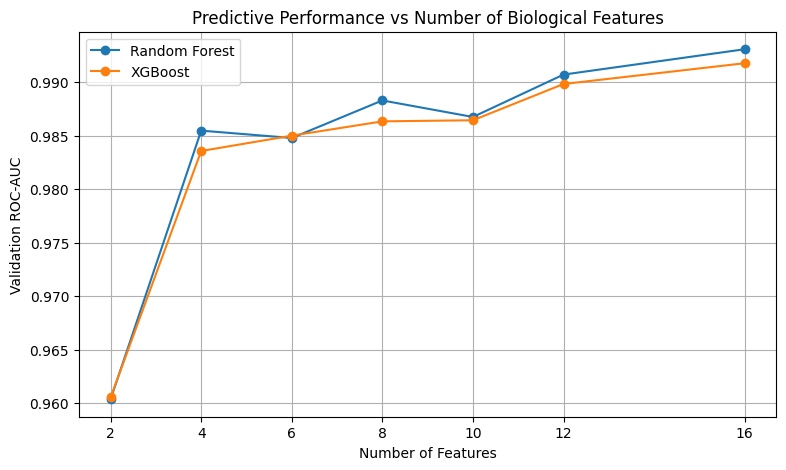

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    topk_rf_df["Features"],
    topk_rf_df["ROC-AUC"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    topk_xgb_df["Features"],
    topk_xgb_df["ROC-AUC"],
    marker="o",
    label="XGBoost"
)

plt.xlabel("Number of Features")
plt.ylabel("Validation ROC-AUC")
plt.title("Predictive Performance vs Number of Biological Features")

plt.xticks(feature_counts)
plt.legend()
plt.grid(True)

plt.show()

In [85]:
print("=" * 70)
print("TOP FEATURES FROM MUTUAL INFORMATION")
print("=" * 70)

for i, row in mi_ranking.head(8).iterrows():
    print(
        f"{i+1}. {row['Feature']:<35} "
        f"MI = {row['MI_Score']:.6f}"
    )

TOP FEATURES FROM MUTUAL INFORMATION
1. gnomad_exome_hom_count              MI = 0.337066
2. vep_impact                          MI = 0.286758
3. gnomad_genome_hom_count             MI = 0.267565
4. protein_length                      MI = 0.188249
5. Molecular consequence               MI = 0.143545
6. vep_variant_class                   MI = 0.096355
7. is_nonsense                         MI = 0.076366
8. relative_protein_position           MI = 0.066889


In [86]:
qnn_features = [
    "gnomad_exome_hom_count",
    "vep_impact",
    "gnomad_genome_hom_count",
    "protein_length"
]

print("=" * 70)
print("OFFICIAL QNN FEATURES")
print("=" * 70)

for i, feature in enumerate(qnn_features, 1):
    print(f"{i}. {feature}")

print("\nFeature count:", len(qnn_features))

OFFICIAL QNN FEATURES
1. gnomad_exome_hom_count
2. vep_impact
3. gnomad_genome_hom_count
4. protein_length

Feature count: 4


In [87]:
X_train_qnn = X_train[qnn_features].copy()
X_val_qnn = X_val[qnn_features].copy()
X_test_qnn = X_test[qnn_features].copy()

print("Training:", X_train_qnn.shape)
print("Validation:", X_val_qnn.shape)
print("Test:", X_test_qnn.shape)

Training: (81977, 4)
Validation: (17567, 4)
Test: (17567, 4)


In [88]:
scale_pos_weight_qnn = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

# --------------------------------------------------
# Logistic Regression
# --------------------------------------------------

lr_qnn = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_qnn.fit(X_train_qnn, y_train)

lr_qnn_results = evaluate_model(
    lr_qnn,
    X_val_qnn,
    y_val,
    "Logistic Regression — Official 4 Features"
)


# --------------------------------------------------
# Random Forest
# --------------------------------------------------

rf_qnn = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_qnn.fit(X_train_qnn, y_train)

rf_qnn_results = evaluate_model(
    rf_qnn,
    X_val_qnn,
    y_val,
    "Random Forest — Official 4 Features"
)


# --------------------------------------------------
# XGBoost
# --------------------------------------------------

xgb_qnn = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight_qnn,
    random_state=42,
    n_jobs=-1
)

xgb_qnn.fit(X_train_qnn, y_train)

xgb_qnn_results = evaluate_model(
    xgb_qnn,
    X_val_qnn,
    y_val,
    "XGBoost — Official 4 Features"
)

Logistic Regression — Official 4 Features
Accuracy            : 0.8093
Balanced Accuracy   : 0.8591
Precision           : 0.9954
Recall              : 0.7254
F1                  : 0.8392
ROC-AUC             : 0.9316
PR-AUC              : 0.9696
MCC                 : 0.6665

Confusion Matrix:
[[5473   40]
 [3310 8744]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6231    0.9927    0.7657      5513
           1     0.9954    0.7254    0.8392     12054

    accuracy                         0.8093     17567
   macro avg     0.8093    0.8591    0.8025     17567
weighted avg     0.8786    0.8093    0.8161     17567

Random Forest — Official 4 Features
Accuracy            : 0.9497
Balanced Accuracy   : 0.9446
Precision           : 0.9680
Recall              : 0.9584
F1                  : 0.9632
ROC-AUC             : 0.9855
PR-AUC              : 0.9910
MCC                 : 0.8841

Confusion Matrix:
[[ 5131   382]
 [  501 11553]]

Classifica

In [89]:
X_train_qnn_tensor = torch.tensor(
    X_train_qnn.values,
    dtype=torch.float32
)

X_val_qnn_tensor = torch.tensor(
    X_val_qnn.values,
    dtype=torch.float32
)

y_train_qnn_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

y_val_qnn_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
).reshape(-1, 1)


train_dataset_qnn = TensorDataset(
    X_train_qnn_tensor,
    y_train_qnn_tensor
)

val_dataset_qnn = TensorDataset(
    X_val_qnn_tensor,
    y_val_qnn_tensor
)

g_qnn = torch.Generator()
g_qnn.manual_seed(42)

train_loader_qnn = DataLoader(
    train_dataset_qnn,
    batch_size=256,
    shuffle=True,
    generator=g_qnn,
    pin_memory=True
)

val_loader_qnn = DataLoader(
    val_dataset_qnn,
    batch_size=256,
    shuffle=False,
    pin_memory=True
)

print("Training batches:", len(train_loader_qnn))
print("Validation batches:", len(val_loader_qnn))

Training batches: 321
Validation batches: 69


In [90]:
class OfficialMLP4(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


mlp_qnn = OfficialMLP4().to(device)

criterion_qnn = nn.BCEWithLogitsLoss()

optimizer_qnn = torch.optim.AdamW(
    mlp_qnn.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler_qnn = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_qnn,
    mode="max",
    factor=0.5,
    patience=4
)

best_auc_qnn = -np.inf
best_state_qnn = None
epochs_without_improvement_qnn = 0

MAX_EPOCHS_QNN = 100
PATIENCE_QNN = 12

history_qnn = []

for epoch in range(1, MAX_EPOCHS_QNN + 1):

    train_loss = train_one_epoch(
        mlp_qnn,
        train_loader_qnn,
        criterion_qnn,
        optimizer_qnn,
        device
    )

    val_loss, val_auc, val_pr, _, _ = evaluate_pytorch(
        mlp_qnn,
        val_loader_qnn,
        criterion_qnn,
        device
    )

    scheduler_qnn.step(val_auc)

    current_lr = optimizer_qnn.param_groups[0]["lr"]

    history_qnn.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_roc_auc": val_auc,
        "val_pr_auc": val_pr,
        "learning_rate": current_lr
    })

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"ROC-AUC: {val_auc:.4f} | "
            f"PR-AUC: {val_pr:.4f}"
        )

    if val_auc > best_auc_qnn:

        best_auc_qnn = val_auc

        best_state_qnn = {
            k: v.detach().cpu().clone()
            for k, v in mlp_qnn.state_dict().items()
        }

        epochs_without_improvement_qnn = 0

    else:

        epochs_without_improvement_qnn += 1

        if epochs_without_improvement_qnn >= PATIENCE_QNN:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

mlp_qnn.load_state_dict(best_state_qnn)

print("\nBest official 4-feature MLP ROC-AUC:", best_auc_qnn)

Epoch 001 | Train Loss: 0.3864 | Val Loss: 0.3148 | ROC-AUC: 0.9120 | PR-AUC: 0.9627
Epoch 010 | Train Loss: 0.2906 | Val Loss: 0.2818 | ROC-AUC: 0.9420 | PR-AUC: 0.9735
Epoch 020 | Train Loss: 0.2557 | Val Loss: 0.2421 | ROC-AUC: 0.9539 | PR-AUC: 0.9782
Epoch 030 | Train Loss: 0.2524 | Val Loss: 0.2305 | ROC-AUC: 0.9593 | PR-AUC: 0.9807
Epoch 040 | Train Loss: 0.2322 | Val Loss: 0.2427 | ROC-AUC: 0.9557 | PR-AUC: 0.9792
Epoch 050 | Train Loss: 0.2170 | Val Loss: 0.2032 | ROC-AUC: 0.9688 | PR-AUC: 0.9847
Epoch 060 | Train Loss: 0.2134 | Val Loss: 0.2156 | ROC-AUC: 0.9657 | PR-AUC: 0.9835

Early stopping at epoch 69.

Best official 4-feature MLP ROC-AUC: 0.9709352309672681


In [91]:
mlp_qnn.eval()

with torch.no_grad():

    logits_qnn = mlp_qnn(
        X_val_qnn_tensor.to(device)
    )

    y_prob_mlp_qnn = (
        torch.sigmoid(logits_qnn)
        .cpu()
        .numpy()
        .ravel()
    )

y_pred_mlp_qnn = (
    y_prob_mlp_qnn >= 0.5
).astype(int)

mlp_qnn_metrics = {
    "Accuracy": accuracy_score(
        y_val,
        y_pred_mlp_qnn
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_val,
        y_pred_mlp_qnn
    ),
    "Precision": precision_score(
        y_val,
        y_pred_mlp_qnn
    ),
    "Recall": recall_score(
        y_val,
        y_pred_mlp_qnn
    ),
    "F1": f1_score(
        y_val,
        y_pred_mlp_qnn
    ),
    "ROC-AUC": roc_auc_score(
        y_val,
        y_prob_mlp_qnn
    ),
    "PR-AUC": average_precision_score(
        y_val,
        y_prob_mlp_qnn
    ),
    "MCC": matthews_corrcoef(
        y_val,
        y_pred_mlp_qnn
    )
}

print("=" * 60)
print("OFFICIAL 4-FEATURE PYTORCH MLP")
print("=" * 60)

for metric, value in mlp_qnn_metrics.items():
    print(f"{metric:<20}: {value:.6f}")

OFFICIAL 4-FEATURE PYTORCH MLP
Accuracy            : 0.910116
Balanced Accuracy   : 0.888143
Precision           : 0.923780
Recall              : 0.947154
F1                  : 0.935321
ROC-AUC             : 0.970936
PR-AUC              : 0.985729
MCC                 : 0.788777


In [92]:
official_4_feature_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Features": 4,
        "ROC-AUC": lr_qnn_results["ROC-AUC"],
        "PR-AUC": lr_qnn_results["PR-AUC"],
        "F1": lr_qnn_results["F1"],
        "MCC": lr_qnn_results["MCC"]
    },
    {
        "Model": "Random Forest",
        "Features": 4,
        "ROC-AUC": rf_qnn_results["ROC-AUC"],
        "PR-AUC": rf_qnn_results["PR-AUC"],
        "F1": rf_qnn_results["F1"],
        "MCC": rf_qnn_results["MCC"]
    },
    {
        "Model": "XGBoost",
        "Features": 4,
        "ROC-AUC": xgb_qnn_results["ROC-AUC"],
        "PR-AUC": xgb_qnn_results["PR-AUC"],
        "F1": xgb_qnn_results["F1"],
        "MCC": xgb_qnn_results["MCC"]
    },
    {
        "Model": "PyTorch MLP",
        "Features": 4,
        "ROC-AUC": mlp_qnn_metrics["ROC-AUC"],
        "PR-AUC": mlp_qnn_metrics["PR-AUC"],
        "F1": mlp_qnn_metrics["F1"],
        "MCC": mlp_qnn_metrics["MCC"]
    }
])

official_4_feature_results = (
    official_4_feature_results
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(official_4_feature_results)

,Model,Features,ROC-AUC,PR-AUC,F1,MCC
0,Random Forest,4,0.985456,0.990975,0.963191,0.884077
1,XGBoost,4,0.983555,0.991834,0.948903,0.842377
2,PyTorch MLP,4,0.970936,0.985729,0.935321,0.788777
3,Logistic Regression,4,0.931604,0.969578,0.839236,0.666508


In [95]:
import pennylane as qml

# Initialize the GPU-accelerated device
dev = qml.device('lightning.gpu', wires=2)

@qml.qnode(dev)
def circuit(x):
    qml.RX(x, wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.expval(qml.PauliZ(1))

print("Circuit output:", circuit(0.5))


Circuit output: 0.8775825618903726


In [97]:
import pennylane as qml

gpu_dev = qml.device("lightning.gpu", wires=4)

print(gpu_dev)
print("Device name:", gpu_dev.name)
print("Number of wires:", len(gpu_dev.wires))

<lightning.gpu device (wires=4) at 0x7f1d6c17be20>
Device name: lightning.gpu
Number of wires: 4


In [98]:
from sklearn.preprocessing import MinMaxScaler

# Fit ONLY on training data
qnn_scaler = MinMaxScaler(
    feature_range=(0, np.pi)
)

X_train_q = qnn_scaler.fit_transform(X_train_qnn)

X_val_q = qnn_scaler.transform(X_val_qnn)

X_test_q = qnn_scaler.transform(X_test_qnn)

print("Training quantum data shape:", X_train_q.shape)
print("Validation quantum data shape:", X_val_q.shape)
print("Test quantum data shape:", X_test_q.shape)

print("\nTraining feature ranges:")
print(
    pd.DataFrame(
        X_train_q,
        columns=qnn_features
    ).describe().loc[["min", "max"]]
)

Training quantum data shape: (81977, 4)
Validation quantum data shape: (17567, 4)
Test quantum data shape: (17567, 4)

Training feature ranges:
     gnomad_exome_hom_count  vep_impact  gnomad_genome_hom_count  \
min                0.000000    0.000000                 0.000000   
max                3.141593    3.141593                 3.141593   

     protein_length  
min        0.000000  
max        3.141593  


In [99]:
print("=" * 70)
print("FIRST 5 QUANTUM-ENCODED SAMPLES")
print("=" * 70)

display(
    pd.DataFrame(
        X_train_q[:5],
        columns=qnn_features
    )
)

print("\nAngle range:")
print("Minimum:", X_train_q.min())
print("Maximum:", X_train_q.max())

FIRST 5 QUANTUM-ENCODED SAMPLES


,gnomad_exome_hom_count,vep_impact,gnomad_genome_hom_count,protein_length
0,0.000000,3.141593,0.000000,0.118248
1,0.000000,3.141593,0.000000,0.103410
2,0.000000,3.141593,0.000000,0.128598
3,0.000000,3.141593,0.000000,0.128598
4,0.000086,0.000000,0.000412,0.141330



Angle range:
Minimum: 0.0
Maximum: 3.141592653589793


In [100]:
import pennylane as qml
import torch
import torch.nn as nn

N_QUBITS = 4
N_LAYERS = 2

qnn_dev = qml.device(
    "lightning.gpu",
    wires=N_QUBITS
)

print(qnn_dev)

<lightning.gpu device (wires=4) at 0x7f1d6c1175b0>


In [101]:
weight_shapes = {
    "weights": (N_LAYERS, N_QUBITS, 2)
}

@qml.qnode(
    qnn_dev,
    interface="torch",
    diff_method="best"
)
def quantum_circuit(inputs, weights):

    # -----------------------------
    # Data encoding
    # -----------------------------
    for i in range(N_QUBITS):
        qml.RY(
            inputs[i],
            wires=i
        )

    # -----------------------------
    # Variational layers
    # -----------------------------
    for layer in range(N_LAYERS):

        for i in range(N_QUBITS):

            qml.RY(
                weights[layer, i, 0],
                wires=i
            )

            qml.RZ(
                weights[layer, i, 1],
                wires=i
            )

        # Ring entanglement
        for i in range(N_QUBITS - 1):
            qml.CNOT(
                wires=[i, i + 1]
            )

        qml.CNOT(
            wires=[N_QUBITS - 1, 0]
        )

    # Quantum measurement
    return qml.expval(
        qml.PauliZ(0)
    )

In [102]:
sample_input = torch.tensor(
    X_train_q[0],
    dtype=torch.float32
)

sample_weights = torch.randn(
    N_LAYERS,
    N_QUBITS,
    2,
    dtype=torch.float32,
    requires_grad=True
)

output = quantum_circuit(
    sample_input,
    sample_weights
)

print("Input:", sample_input)
print("Quantum output:", output)
print("Output type:", type(output))

Input: tensor([0.0000, 3.1416, 0.0000, 0.1182])
Quantum output: tensor(0.1315, grad_fn=<ExecuteTapesBackward>)
Output type: <class 'torch.Tensor'>


In [103]:
sample_weights.grad = None

output = quantum_circuit(
    sample_input,
    sample_weights
)

output.backward()

print("Quantum output:", output.item())

print(
    "Gradient shape:",
    sample_weights.grad.shape
)

print(
    "Gradient norm:",
    sample_weights.grad.norm().item()
)

Quantum output: 0.13149821758270264
Gradient shape: torch.Size([2, 4, 2])
Gradient norm: 0.5924556851387024


In [104]:
import torch
import torch.nn as nn
import pennylane as qml

class HybridQNN(nn.Module):
    def __init__(self, n_qubits=4, n_layers=2):
        super().__init__()

        self.n_qubits = n_qubits
        self.n_layers = n_layers

        # Trainable quantum parameters
        self.weights = nn.Parameter(
            0.01 * torch.randn(n_layers, n_qubits, 2)
        )

        # Classical output layer
        self.classical = nn.Linear(1, 1)

    def forward(self, x):

        quantum_outputs = []

        for sample in x:
            q_out = quantum_circuit(
                sample,
                self.weights
            )

            quantum_outputs.append(q_out)

        quantum_outputs = torch.stack(quantum_outputs)

        # Shape: (batch_size, 1)
        quantum_outputs = quantum_outputs.unsqueeze(1)

        # Classical transformation → logit
        logits = self.classical(quantum_outputs)

        return logits.squeeze(1)

In [105]:
qnn_model = HybridQNN(
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS
)

print(qnn_model)

HybridQNN(
  (classical): Linear(in_features=1, out_features=1, bias=True)
)


In [106]:
X_test_batch = torch.tensor(
    X_train_q[:8],
    dtype=torch.float32
)

with torch.no_grad():
    batch_output = qnn_model(X_test_batch)

print("Input shape:", X_test_batch.shape)
print("Output shape:", batch_output.shape)
print("Outputs:", batch_output)

Input shape: torch.Size([8, 4])
Output shape: torch.Size([8])
Outputs: tensor([0.2684, 0.2674, 0.2692, 0.2692, 1.6419, 1.6478, 0.2645, 1.6471])


In [107]:
# Create a small batch
X_batch = torch.tensor(
    X_train_q[:8],
    dtype=torch.float32
)

y_batch = torch.tensor(
    y_train.iloc[:8].values,
    dtype=torch.float32
)

# Loss function
criterion = nn.BCEWithLogitsLoss()

# Forward pass
logits = qnn_model(X_batch)

# Calculate loss
loss = criterion(logits, y_batch)

# Backward pass
qnn_model.zero_grad()
loss.backward()

print("Loss:", loss.item())
print("Quantum gradient norm:", qnn_model.weights.grad.norm().item())
print("Classical gradient norm:", qnn_model.classical.weight.grad.norm().item())

Loss: 0.8323928117752075
Quantum gradient norm: 0.03057597577571869
Classical gradient norm: 0.4578290581703186


In [108]:
from torch.utils.data import TensorDataset, DataLoader

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_q, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_q, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

# Dataset
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

# DataLoader
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Batch size:", BATCH_SIZE)
print("Number of training batches:", len(train_loader))

Training samples: 81977
Validation samples: 17567
Batch size: 32
Number of training batches: 2562


In [109]:
qnn_model = HybridQNN(
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS
).to("cuda")

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    qnn_model.parameters(),
    lr=0.01,
    weight_decay=1e-4
)

print(qnn_model)
print("\nDevice:", next(qnn_model.parameters()).device)

HybridQNN(
  (classical): Linear(in_features=1, out_features=1, bias=True)
)

Device: cuda:0


In [110]:
import time

qnn_model.train()

X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to("cuda")
y_batch = y_batch.to("cuda")

start_time = time.time()

optimizer.zero_grad()

logits = qnn_model(X_batch)

loss = criterion(logits, y_batch)

loss.backward()

optimizer.step()

elapsed = time.time() - start_time

print("Batch shape:", X_batch.shape)
print("Loss:", loss.item())
print("Time for one batch:", round(elapsed, 2), "seconds")

Batch shape: torch.Size([32, 4])
Loss: 0.8545540571212769
Time for one batch: 0.43 seconds


In [111]:
import time
from sklearn.metrics import roc_auc_score, average_precision_score

EPOCHS = 3

for epoch in range(EPOCHS):

    epoch_start = time.time()

    # -------------------------
    # TRAIN
    # -------------------------
    qnn_model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to("cuda")
        y_batch = y_batch.to("cuda")

        optimizer.zero_grad()

        logits = qnn_model(X_batch)

        loss = criterion(logits, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # -------------------------
    # VALIDATION
    # -------------------------
    qnn_model.eval()

    val_loss = 0.0
    val_probs = []
    val_targets = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to("cuda")
            y_batch = y_batch.to("cuda")

            logits = qnn_model(X_batch)

            loss = criterion(logits, y_batch)

            val_loss += loss.item() * X_batch.size(0)

            probs = torch.sigmoid(logits)

            val_probs.extend(probs.cpu().numpy())
            val_targets.extend(y_batch.cpu().numpy())

    val_loss /= len(val_loader.dataset)

    val_auc = roc_auc_score(
        val_targets,
        val_probs
    )

    val_pr_auc = average_precision_score(
        val_targets,
        val_probs
    )

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val ROC-AUC: {val_auc:.4f} | "
        f"Val PR-AUC: {val_pr_auc:.4f} | "
        f"Time: {epoch_time/60:.2f} min"
    )

Epoch 1/3 | Train Loss: 0.3769 | Val Loss: 0.3392 | Val ROC-AUC: 0.9003 | Val PR-AUC: 0.9577 | Time: 16.36 min
Epoch 2/3 | Train Loss: 0.3417 | Val Loss: 0.3335 | Val ROC-AUC: 0.9024 | Val PR-AUC: 0.9583 | Time: 15.82 min
Epoch 3/3 | Train Loss: 0.3389 | Val Loss: 0.3355 | Val ROC-AUC: 0.9032 | Val PR-AUC: 0.9591 | Time: 15.63 min


In [112]:
@qml.qnode(qnn_dev, interface="torch", diff_method="best")
def quantum_circuit_all(inputs, weights):

    # Angle encoding
    for i in range(N_QUBITS):
        qml.RY(inputs[i], wires=i)

    # Variational layers
    for layer in range(N_LAYERS):

        for i in range(N_QUBITS):
            qml.RY(
                weights[layer, i, 0],
                wires=i
            )

            qml.RZ(
                weights[layer, i, 1],
                wires=i
            )

        # Ring entanglement
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])

        qml.CNOT(wires=[N_QUBITS - 1, 0])

    # Measure ALL qubits
    return [
        qml.expval(qml.PauliZ(i))
        for i in range(N_QUBITS)
    ]

In [113]:
sample_input = torch.tensor(
    X_train_q[0],
    dtype=torch.float32
)

sample_weights = torch.randn(
    N_LAYERS,
    N_QUBITS,
    2,
    dtype=torch.float32,
    requires_grad=True
)

output = quantum_circuit_all(
    sample_input,
    sample_weights
)

print("Quantum output:", output)
print("Number of outputs:", len(output))

Quantum output: [tensor(0.2131, grad_fn=<ExecuteTapesBackward>), tensor(-0.2117, grad_fn=<ExecuteTapesBackward>), tensor(-0.3528, grad_fn=<ExecuteTapesBackward>), tensor(-0.5613, grad_fn=<ExecuteTapesBackward>)]
Number of outputs: 4


In [114]:
class HybridQNNv2(nn.Module):

    def __init__(self, n_qubits=4, n_layers=2):
        super().__init__()

        self.n_qubits = n_qubits
        self.n_layers = n_layers

        # Trainable quantum parameters
        self.weights = nn.Parameter(
            0.01 * torch.randn(
                n_layers,
                n_qubits,
                2
            )
        )

        # Classical head:
        # 4 quantum measurements → 1 prediction
        self.classical = nn.Linear(
            n_qubits,
            1
        )

    def forward(self, x):

        quantum_outputs = []

        for sample in x:

            q_out = quantum_circuit_all(
                sample,
                self.weights
            )

            q_out = torch.stack(q_out)

            quantum_outputs.append(q_out)

        # (batch_size, 4)
        quantum_outputs = torch.stack(
            quantum_outputs
        )

        # (batch_size, 4) → (batch_size, 1)
        logits = self.classical(
            quantum_outputs
        )

        return logits.squeeze(1)

In [115]:
qnn_model_v2 = HybridQNNv2(
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS
).to("cuda")

X_batch = torch.tensor(
    X_train_q[:8],
    dtype=torch.float32
).to("cuda")

with torch.no_grad():

    logits = qnn_model_v2(X_batch)

print("Input shape:", X_batch.shape)
print("Output shape:", logits.shape)
print("Outputs:", logits)

Input shape: torch.Size([8, 4])
Output shape: torch.Size([8])
Outputs: tensor([ 0.1813,  0.1822,  0.1806,  0.1806, -1.3134, -1.3245,  0.1851, -1.3227],
       device='cuda:0')


In [116]:
y_batch = torch.tensor(
    y_train.iloc[:8].values,
    dtype=torch.float32
).to("cuda")

criterion = nn.BCEWithLogitsLoss()

logits = qnn_model_v2(X_batch)

loss = criterion(
    logits,
    y_batch
)

qnn_model_v2.zero_grad()

loss.backward()

print("Loss:", loss.item())
print(
    "Quantum gradient norm:",
    qnn_model_v2.weights.grad.norm().item()
)
print(
    "Classical gradient norm:",
    qnn_model_v2.classical.weight.grad.norm().item()
)

Loss: 0.6332671046257019
Quantum gradient norm: 0.01898937299847603
Classical gradient norm: 0.5727170705795288


In [117]:
qnn_model = HybridQNNv2(
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS
).to("cuda")

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    qnn_model.parameters(),
    lr=0.01,
    weight_decay=1e-4
)

print("Model initialized.")
print("Device:", next(qnn_model.parameters()).device)

Model initialized.
Device: cuda:0


In [118]:
import time

qnn_model.train()

X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to("cuda")
y_batch = y_batch.to("cuda")

start_time = time.time()

optimizer.zero_grad()

logits = qnn_model(X_batch)

loss = criterion(
    logits,
    y_batch
)

loss.backward()

optimizer.step()

elapsed = time.time() - start_time

print("Batch shape:", X_batch.shape)
print("Loss:", loss.item())
print("Time for one batch:", round(elapsed, 2), "seconds")

Batch shape: torch.Size([32, 4])
Loss: 0.6547830104827881
Time for one batch: 0.7 seconds


In [119]:
import time
from sklearn.metrics import roc_auc_score, average_precision_score

EPOCHS = 3

qnn_history = []

for epoch in range(EPOCHS):

    epoch_start = time.time()

    # =========================
    # TRAIN
    # =========================
    qnn_model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to("cuda")
        y_batch = y_batch.to("cuda")

        optimizer.zero_grad()

        logits = qnn_model(X_batch)

        loss = criterion(logits, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # =========================
    # VALIDATION
    # =========================
    qnn_model.eval()

    val_loss = 0.0
    val_probs = []
    val_targets = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to("cuda")
            y_batch = y_batch.to("cuda")

            logits = qnn_model(X_batch)

            loss = criterion(logits, y_batch)

            val_loss += loss.item() * X_batch.size(0)

            probs = torch.sigmoid(logits)

            val_probs.extend(
                probs.cpu().numpy()
            )

            val_targets.extend(
                y_batch.cpu().numpy()
            )

    val_loss /= len(val_loader.dataset)

    val_auc = roc_auc_score(
        val_targets,
        val_probs
    )

    val_pr_auc = average_precision_score(
        val_targets,
        val_probs
    )

    epoch_time = time.time() - epoch_start

    qnn_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "roc_auc": val_auc,
        "pr_auc": val_pr_auc,
        "time_min": epoch_time / 60
    })

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val ROC-AUC: {val_auc:.4f} | "
        f"Val PR-AUC: {val_pr_auc:.4f} | "
        f"Time: {epoch_time/60:.2f} min"
    )

Epoch 1/3 | Train Loss: 0.3533 | Val Loss: 0.3394 | Val ROC-AUC: 0.8998 | Val PR-AUC: 0.9578 | Time: 30.25 min
Epoch 2/3 | Train Loss: 0.3406 | Val Loss: 0.3311 | Val ROC-AUC: 0.9061 | Val PR-AUC: 0.9602 | Time: 32.32 min
Epoch 3/3 | Train Loss: 0.3322 | Val Loss: 0.3293 | Val ROC-AUC: 0.9072 | Val PR-AUC: 0.9606 | Time: 32.30 min


In [120]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

qnn_model.eval()

val_probs = []
val_targets = []

with torch.no_grad():

    for X_batch, y_batch in val_loader:

        X_batch = X_batch.to("cuda")

        logits = qnn_model(X_batch)

        probs = torch.sigmoid(logits)

        val_probs.extend(
            probs.cpu().numpy()
        )

        val_targets.extend(
            y_batch.numpy()
        )

# Convert to arrays
val_probs = np.array(val_probs)
val_targets = np.array(val_targets)

# Classification threshold
val_pred = (val_probs >= 0.5).astype(int)

# Metrics
qnn_accuracy = accuracy_score(
    val_targets,
    val_pred
)

qnn_balanced_accuracy = balanced_accuracy_score(
    val_targets,
    val_pred
)

qnn_precision = precision_score(
    val_targets,
    val_pred
)

qnn_recall = recall_score(
    val_targets,
    val_pred
)

qnn_f1 = f1_score(
    val_targets,
    val_pred
)

qnn_roc_auc = roc_auc_score(
    val_targets,
    val_probs
)

qnn_pr_auc = average_precision_score(
    val_targets,
    val_probs
)

qnn_mcc = matthews_corrcoef(
    val_targets,
    val_pred
)

qnn_cm = confusion_matrix(
    val_targets,
    val_pred
)

print("=" * 60)
print("QNN v2 — FINAL VALIDATION RESULTS")
print("=" * 60)

print(f"Accuracy:           {qnn_accuracy:.6f}")
print(f"Balanced Accuracy:  {qnn_balanced_accuracy:.6f}")
print(f"Precision:          {qnn_precision:.6f}")
print(f"Recall:             {qnn_recall:.6f}")
print(f"F1 Score:           {qnn_f1:.6f}")
print(f"ROC-AUC:            {qnn_roc_auc:.6f}")
print(f"PR-AUC:             {qnn_pr_auc:.6f}")
print(f"MCC:                {qnn_mcc:.6f}")

print("\nConfusion Matrix:")
print(qnn_cm)

print("\nClassification Report:")
print(
    classification_report(
        val_targets,
        val_pred,
        digits=4
    )
)

QNN v2 — FINAL VALIDATION RESULTS
Accuracy:           0.828599
Balanced Accuracy:  0.821017
Precision:          0.902233
Recall:             0.841380
F1 Score:           0.870745
ROC-AUC:            0.907189
PR-AUC:             0.960627
MCC:                0.620655

Confusion Matrix:
[[ 4414  1099]
 [ 1912 10142]]

Classification Report:
              precision    recall  f1-score   support

         0.0     0.6978    0.8007    0.7457      5513
         1.0     0.9022    0.8414    0.8707     12054

    accuracy                         0.8286     17567
   macro avg     0.8000    0.8210    0.8082     17567
weighted avg     0.8381    0.8286    0.8315     17567



In [121]:
import os
import torch
import json

# Create model directory
os.makedirs("Data/qnn_model", exist_ok=True)

# Save model state
qnn_model_path = "Data/qnn_model/qnn_v2_state_dict.pt"

torch.save(
    qnn_model.state_dict(),
    qnn_model_path
)

print("Saved:", qnn_model_path)

Saved: Data/qnn_model/qnn_v2_state_dict.pt


In [122]:
qnn_config = {
    "model": "HybridQNNv2",
    "n_qubits": N_QUBITS,
    "n_layers": N_LAYERS,
    "features": qnn_features,
    "batch_size": BATCH_SIZE,
    "optimizer": "AdamW",
    "learning_rate": 0.01,
    "weight_decay": 1e-4,
    "loss": "BCEWithLogitsLoss",
    "quantum_device": "lightning.gpu",
    "epochs_trained": 3,
    "best_validation_epoch": 3
}

qnn_config_path = "Data/qnn_model/qnn_v2_config.json"

with open(qnn_config_path, "w") as f:
    json.dump(qnn_config, f, indent=4)

print("Saved:", qnn_config_path)

Saved: Data/qnn_model/qnn_v2_config.json


In [123]:
import joblib

qnn_scaler_path = "Data/qnn_model/qnn_scaler.pkl"

joblib.dump(
    qnn_scaler,
    qnn_scaler_path
)

print("Saved:", qnn_scaler_path)

Saved: Data/qnn_model/qnn_scaler.pkl


In [124]:
qnn_features_path = "Data/qnn_model/qnn_features.json"

with open(qnn_features_path, "w") as f:
    json.dump(qnn_features, f, indent=4)

print("Saved:", qnn_features_path)

Saved: Data/qnn_model/qnn_features.json


In [125]:
import pandas as pd

qnn_history_df = pd.DataFrame(qnn_history)

qnn_history_path = "Data/qnn_model/qnn_v2_training_history.csv"

qnn_history_df.to_csv(
    qnn_history_path,
    index=False
)

print("Saved:", qnn_history_path)

display(qnn_history_df)

Saved: Data/qnn_model/qnn_v2_training_history.csv


,epoch,train_loss,val_loss,roc_auc,pr_auc,time_min
0,1,0.353321,0.339356,0.899762,0.957784,30.250543
1,2,0.340601,0.331064,0.906076,0.960168,32.315354
2,3,0.332160,0.329283,0.907189,0.960627,32.302048


In [126]:
validation_leaderboard = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Features": 4,
        "ROC-AUC": 0.985456,
        "PR-AUC": 0.990975,
        "F1": 0.963191,
        "MCC": 0.884077
    },
    {
        "Model": "XGBoost",
        "Features": 4,
        "ROC-AUC": 0.983555,
        "PR-AUC": 0.991834,
        "F1": 0.948903,
        "MCC": 0.842377
    },
    {
        "Model": "PyTorch MLP",
        "Features": 4,
        "ROC-AUC": 0.970936,
        "PR-AUC": 0.985729,
        "F1": 0.935321,
        "MCC": 0.788777
    },
    {
        "Model": "Logistic Regression",
        "Features": 4,
        "ROC-AUC": 0.931604,
        "PR-AUC": 0.969578,
        "F1": 0.839236,
        "MCC": 0.665080
    },
    {
        "Model": "QNN v1",
        "Features": 4,
        "ROC-AUC": 0.903200,
        "PR-AUC": 0.959100,
        "F1": None,
        "MCC": None
    },
    {
        "Model": "QNN v2",
        "Features": 4,
        "ROC-AUC": qnn_roc_auc,
        "PR-AUC": qnn_pr_auc,
        "F1": qnn_f1,
        "MCC": qnn_mcc
    }
])

validation_leaderboard = validation_leaderboard.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(validation_leaderboard)

,Model,Features,ROC-AUC,PR-AUC,F1,MCC
0,Random Forest,4,0.985456,0.990975,0.963191,0.884077
1,XGBoost,4,0.983555,0.991834,0.948903,0.842377
2,PyTorch MLP,4,0.970936,0.985729,0.935321,0.788777
3,Logistic Regression,4,0.931604,0.969578,0.839236,0.665080
4,QNN v2,4,0.907189,0.960627,0.870745,0.620655
5,QNN v1,4,0.903200,0.959100,NaN,NaN


In [127]:
leaderboard_path = "Data/qnn_model/validation_leaderboard.csv"

validation_leaderboard.to_csv(
    leaderboard_path,
    index=False
)

print("Saved:", leaderboard_path)

Saved: Data/qnn_model/validation_leaderboard.csv


In [128]:
qnn_features = [
    "gnomad_exome_hom_count",
    "vep_impact",
    "gnomad_genome_hom_count",
    "protein_length"
]

In [129]:
# Official compact feature set
compact_features = [
    "gnomad_exome_hom_count",
    "vep_impact",
    "gnomad_genome_hom_count",
    "protein_length"
]

# Training
X_train_4 = train_df[compact_features].copy()
y_train_4 = train_df["label"].copy()

# Validation
X_val_4 = val_df[compact_features].copy()
y_val_4 = val_df["label"].copy()

# Test
X_test_4 = test_df[compact_features].copy()
y_test_4 = test_df["label"].copy()

print("Training:", X_train_4.shape)
print("Validation:", X_val_4.shape)
print("Test:", X_test_4.shape)

print("\nFeatures:")
for i, feature in enumerate(compact_features, 1):
    print(f"{i}. {feature}")

Training: (81977, 4)
Validation: (17567, 4)
Test: (17567, 4)

Features:
1. gnomad_exome_hom_count
2. vep_impact
3. gnomad_genome_hom_count
4. protein_length


In [130]:
from sklearn.ensemble import RandomForestClassifier

rf_4 = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_4.fit(
    X_train_4,
    y_train_4
)

print("Random Forest trained.")

Random Forest trained.


In [131]:
rf_val_probs = rf_4.predict_proba(X_val_4)[:, 1]
rf_val_pred = (rf_val_probs >= 0.5).astype(int)

print("=" * 60)
print("RANDOM FOREST — 4 FEATURES — VALIDATION")
print("=" * 60)

print(
    f"Accuracy:          "
    f"{accuracy_score(y_val_4, rf_val_pred):.6f}"
)

print(
    f"Balanced Accuracy: "
    f"{balanced_accuracy_score(y_val_4, rf_val_pred):.6f}"
)

print(
    f"Precision:         "
    f"{precision_score(y_val_4, rf_val_pred):.6f}"
)

print(
    f"Recall:            "
    f"{recall_score(y_val_4, rf_val_pred):.6f}"
)

print(
    f"F1:                "
    f"{f1_score(y_val_4, rf_val_pred):.6f}"
)

print(
    f"ROC-AUC:           "
    f"{roc_auc_score(y_val_4, rf_val_probs):.6f}"
)

print(
    f"PR-AUC:            "
    f"{average_precision_score(y_val_4, rf_val_probs):.6f}"
)

print(
    f"MCC:               "
    f"{matthews_corrcoef(y_val_4, rf_val_pred):.6f}"
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_4, rf_val_pred))

RANDOM FOREST — 4 FEATURES — VALIDATION
Accuracy:          0.949735
Balanced Accuracy: 0.944573
Precision:         0.967993
Recall:            0.958437
F1:                0.963191
ROC-AUC:           0.985456
PR-AUC:            0.990975
MCC:               0.884077

Confusion Matrix:
[[ 5131   382]
 [  501 11553]]


In [132]:
from xgboost import XGBClassifier

negative_count = (y_train_4 == 0).sum()
positive_count = (y_train_4 == 1).sum()

scale_pos_weight = negative_count / positive_count

xgb_4 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_4.fit(
    X_train_4,
    y_train_4
)

print("XGBoost trained.")
print("scale_pos_weight:", scale_pos_weight)

XGBoost trained.
scale_pos_weight: 0.45739479812974454


In [133]:
xgb_val_probs = xgb_4.predict_proba(X_val_4)[:, 1]
xgb_val_pred = (xgb_val_probs >= 0.5).astype(int)

print("=" * 60)
print("XGBOOST — 4 FEATURES — VALIDATION")
print("=" * 60)

print(
    f"Accuracy:          "
    f"{accuracy_score(y_val_4, xgb_val_pred):.6f}"
)

print(
    f"Balanced Accuracy: "
    f"{balanced_accuracy_score(y_val_4, xgb_val_pred):.6f}"
)

print(
    f"Precision:         "
    f"{precision_score(y_val_4, xgb_val_pred):.6f}"
)

print(
    f"Recall:            "
    f"{recall_score(y_val_4, xgb_val_pred):.6f}"
)

print(
    f"F1:                "
    f"{f1_score(y_val_4, xgb_val_pred):.6f}"
)

print(
    f"ROC-AUC:           "
    f"{roc_auc_score(y_val_4, xgb_val_probs):.6f}"
)

print(
    f"PR-AUC:            "
    f"{average_precision_score(y_val_4, xgb_val_probs):.6f}"
)

print(
    f"MCC:               "
    f"{matthews_corrcoef(y_val_4, xgb_val_pred):.6f}"
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_4, xgb_val_pred))

XGBOOST — 4 FEATURES — VALIDATION
Accuracy:          0.930779
Balanced Accuracy: 0.927266
Precision:         0.961427
Recall:            0.936702
F1:                0.948903
ROC-AUC:           0.983555
PR-AUC:            0.991834
MCC:               0.842377

Confusion Matrix:
[[ 5060   453]
 [  763 11291]]


In [134]:
from sklearn.linear_model import LogisticRegression

lr_4 = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_4.fit(
    X_train_4,
    y_train_4
)

print("Logistic Regression trained.")

Logistic Regression trained.


In [135]:
lr_val_probs = lr_4.predict_proba(X_val_4)[:, 1]
lr_val_pred = (lr_val_probs >= 0.5).astype(int)

print("=" * 60)
print("LOGISTIC REGRESSION — 4 FEATURES — VALIDATION")
print("=" * 60)

print(f"Accuracy:          {accuracy_score(y_val_4, lr_val_pred):.6f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val_4, lr_val_pred):.6f}")
print(f"Precision:         {precision_score(y_val_4, lr_val_pred):.6f}")
print(f"Recall:            {recall_score(y_val_4, lr_val_pred):.6f}")
print(f"F1:                {f1_score(y_val_4, lr_val_pred):.6f}")
print(f"ROC-AUC:           {roc_auc_score(y_val_4, lr_val_probs):.6f}")
print(f"PR-AUC:            {average_precision_score(y_val_4, lr_val_probs):.6f}")
print(f"MCC:               {matthews_corrcoef(y_val_4, lr_val_pred):.6f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_4, lr_val_pred))

LOGISTIC REGRESSION — 4 FEATURES — VALIDATION
Accuracy:          0.809302
Balanced Accuracy: 0.859073
Precision:         0.995446
Recall:            0.725402
F1:                0.839236
ROC-AUC:           0.931604
PR-AUC:            0.969578
MCC:               0.666508

Confusion Matrix:
[[5473   40]
 [3310 8744]]


In [136]:
import torch
import torch.nn as nn
import numpy as np

class MLP4(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

In [137]:
X_train_4_tensor = torch.tensor(
    X_train_4.values,
    dtype=torch.float32
)

y_train_4_tensor = torch.tensor(
    y_train_4.values,
    dtype=torch.float32
)

X_val_4_tensor = torch.tensor(
    X_val_4.values,
    dtype=torch.float32
)

y_val_4_tensor = torch.tensor(
    y_val_4.values,
    dtype=torch.float32
)

train_dataset_4 = torch.utils.data.TensorDataset(
    X_train_4_tensor,
    y_train_4_tensor
)

train_loader_4 = torch.utils.data.DataLoader(
    train_dataset_4,
    batch_size=256,
    shuffle=True
)

print("Training shape:", X_train_4_tensor.shape)
print("Validation shape:", X_val_4_tensor.shape)

Training shape: torch.Size([81977, 4])
Validation shape: torch.Size([17567, 4])


In [138]:
torch.manual_seed(42)

mlp_4 = MLP4().to("cuda")

criterion_mlp = nn.BCEWithLogitsLoss()

optimizer_mlp = torch.optim.Adam(
    mlp_4.parameters(),
    lr=0.001
)

EPOCHS_MLP = 100

for epoch in range(EPOCHS_MLP):

    mlp_4.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader_4:

        X_batch = X_batch.to("cuda")
        y_batch = y_batch.to("cuda")

        optimizer_mlp.zero_grad()

        logits = mlp_4(X_batch)

        loss = criterion_mlp(
            logits,
            y_batch
        )

        loss.backward()

        optimizer_mlp.step()

        train_loss += (
            loss.item() * X_batch.size(0)
        )

    train_loss /= len(train_loader_4.dataset)

    # Validation
    mlp_4.eval()

    with torch.no_grad():

        val_logits = mlp_4(
            X_val_4_tensor.to("cuda")
        )

        val_probs_mlp = torch.sigmoid(
            val_logits
        ).cpu().numpy()

    val_auc_mlp = roc_auc_score(
        y_val_4,
        val_probs_mlp
    )

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val ROC-AUC: {val_auc_mlp:.4f}"
        )

Epoch  10 | Train Loss: 0.2993 | Val ROC-AUC: 0.9312
Epoch  20 | Train Loss: 0.2846 | Val ROC-AUC: 0.9401
Epoch  30 | Train Loss: 0.2750 | Val ROC-AUC: 0.9449
Epoch  40 | Train Loss: 0.2676 | Val ROC-AUC: 0.9493
Epoch  50 | Train Loss: 0.2625 | Val ROC-AUC: 0.9498
Epoch  60 | Train Loss: 0.2592 | Val ROC-AUC: 0.9543
Epoch  70 | Train Loss: 0.2560 | Val ROC-AUC: 0.9563
Epoch  80 | Train Loss: 0.2511 | Val ROC-AUC: 0.9543
Epoch  90 | Train Loss: 0.2484 | Val ROC-AUC: 0.9581
Epoch 100 | Train Loss: 0.2475 | Val ROC-AUC: 0.9576


In [139]:
mlp_4.eval()

with torch.no_grad():

    mlp_val_logits = mlp_4(
        X_val_4_tensor.to("cuda")
    )

    mlp_val_probs = torch.sigmoid(
        mlp_val_logits
    ).cpu().numpy()

mlp_val_pred = (
    mlp_val_probs >= 0.5
).astype(int)

print("=" * 60)
print("PYTORCH MLP — 4 FEATURES — VALIDATION")
print("=" * 60)

print(f"Accuracy:          {accuracy_score(y_val_4, mlp_val_pred):.6f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val_4, mlp_val_pred):.6f}")
print(f"Precision:         {precision_score(y_val_4, mlp_val_pred):.6f}")
print(f"Recall:            {recall_score(y_val_4, mlp_val_pred):.6f}")
print(f"F1:                {f1_score(y_val_4, mlp_val_pred):.6f}")
print(f"ROC-AUC:           {roc_auc_score(y_val_4, mlp_val_probs):.6f}")
print(f"PR-AUC:            {average_precision_score(y_val_4, mlp_val_probs):.6f}")
print(f"MCC:               {matthews_corrcoef(y_val_4, mlp_val_pred):.6f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_4, mlp_val_pred))

PYTORCH MLP — 4 FEATURES — VALIDATION
Accuracy:          0.884442
Balanced Accuracy: 0.855409
Precision:         0.901667
Recall:            0.933383
F1:                0.917251
ROC-AUC:           0.957602
PR-AUC:            0.980233
MCC:               0.727159

Confusion Matrix:
[[ 4286  1227]
 [  803 11251]]


In [146]:
import os
import joblib

os.makedirs("Data/final_models", exist_ok=True)

joblib.dump(
    rf_4,
    "Data/final_models/random_forest_4.pkl"
)

joblib.dump(
    xgb_4,
    "Data/final_models/xgboost_4.pkl"
)

joblib.dump(
    lr_4,
    "Data/final_models/logistic_regression_4.pkl"
)

print("Saved:")
print("  random_forest_4.pkl")
print("  xgboost_4.pkl")
print("  logistic_regression_4.pkl")

Saved:
  random_forest_4.pkl
  xgboost_4.pkl
  logistic_regression_4.pkl


In [147]:
torch.save(
    qnn_model.state_dict(),
    "Data/final_models/qnn_v2.pt"
)

print("Saved: qnn_v2.pt")

Saved: qnn_v2.pt


In [151]:
print(model_4)

print("\nModel parameters:")

for name, param in model_4.named_parameters():
    print(name, tuple(param.shape))

model_4.eval()

with torch.no_grad():

    val_logits = model_4(
        torch.tensor(
            X_val_4.values,
            dtype=torch.float32
        ).to("cuda")
    )

    model_4_val_probs = torch.sigmoid(
        val_logits
    ).cpu().numpy()

model_4_val_pred = (
    model_4_val_probs >= 0.5
).astype(int)

print("=" * 60)
print("ORIGINAL MODEL_4 — VALIDATION")
print("=" * 60)

print(f"Accuracy:          {accuracy_score(y_val_4, model_4_val_pred):.6f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val_4, model_4_val_pred):.6f}")
print(f"Precision:         {precision_score(y_val_4, model_4_val_pred):.6f}")
print(f"Recall:            {recall_score(y_val_4, model_4_val_pred):.6f}")
print(f"F1:                {f1_score(y_val_4, model_4_val_pred):.6f}")
print(f"ROC-AUC:           {roc_auc_score(y_val_4, model_4_val_probs):.6f}")
print(f"PR-AUC:            {average_precision_score(y_val_4, model_4_val_probs):.6f}")
print(f"MCC:               {matthews_corrcoef(y_val_4, model_4_val_pred):.6f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_4, model_4_val_pred))

MLP4(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)

Model parameters:
network.0.weight (64, 4)
network.0.bias (64,)
network.3.weight (32, 64)
network.3.bias (32,)
network.6.weight (16, 32)
network.6.bias (16,)
network.8.weight (1, 16)
network.8.bias (1,)
ORIGINAL MODEL_4 — VALIDATION
Accuracy:          0.682701
Balanced Accuracy: 0.735915
Precision:         0.914534
Recall:            0.592998
F1:                0.719477
ROC-AUC:           0.765088
PR-AUC:            0.898998
MCC:               0.440584

Confusion Matrix:
[[4845  668]
 [4906 7148]]


In [152]:
model_4.eval()

with torch.no_grad():

    X_val_gpu_4 = X_val_4_tensor.to(device)

    logits_4 = model_4(X_val_gpu_4)

    y_prob_mlp4 = torch.sigmoid(logits_4).cpu().numpy().ravel()

y_pred_mlp4 = (y_prob_mlp4 >= 0.5).astype(int)

mlp_4_metrics = {
    "Accuracy": accuracy_score(y_val, y_pred_mlp4),
    "Balanced Accuracy": balanced_accuracy_score(y_val, y_pred_mlp4),
    "Precision": precision_score(y_val, y_pred_mlp4),
    "Recall": recall_score(y_val, y_pred_mlp4),
    "F1": f1_score(y_val, y_pred_mlp4),
    "ROC-AUC": roc_auc_score(y_val, y_prob_mlp4),
    "PR-AUC": average_precision_score(y_val, y_prob_mlp4),
    "MCC": matthews_corrcoef(y_val, y_pred_mlp4)
}

print("=" * 60)
print("PYTORCH MLP — 4 FEATURES")
print("=" * 60)

for metric, value in mlp_4_metrics.items():
    print(f"{metric:<20}: {value:.6f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_mlp4))

PYTORCH MLP — 4 FEATURES
Accuracy            : 0.682701
Balanced Accuracy   : 0.735915
Precision           : 0.914534
Recall              : 0.592998
F1                  : 0.719477
ROC-AUC             : 0.765088
PR-AUC              : 0.898998
MCC                 : 0.440584

Confusion Matrix:
[[4845  668]
 [4906 7148]]


In [159]:
import os
import torch

os.makedirs("Data/final_models", exist_ok=True)

mlp_model_path = "Data/final_models/mlp_4.pt"

torch.save(
    model_4.state_dict(),
    mlp_model_path
)

print("Saved frozen MLP:", mlp_model_path)

Saved frozen MLP: Data/final_models/mlp_4.pt


In [160]:
model_4.eval()

MLP4(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [161]:
for param in model_4.parameters():
    param.requires_grad = False

model_4.eval()

print("MLP frozen.")

MLP frozen.


In [162]:
import json

mlp_config = {
    "model": "PyTorch MLP",
    "features": compact_features,
    "input_features": len(compact_features),
    "device": str(device),
    "frozen": True
}

with open(
    "Data/final_models/mlp_4_config.json",
    "w"
) as f:
    json.dump(mlp_config, f, indent=4)

print("MLP configuration saved.")

MLP configuration saved.


In [163]:
# Final test data — 4 official features
X_test_4 = test_df[compact_features].copy()
y_test_4 = test_df["label"].copy()

print("Test shape:", X_test_4.shape)
print("Test labels:", y_test_4.shape)

print("\nFeatures:")
for i, feature in enumerate(compact_features, 1):
    print(f"{i}. {feature}")

Test shape: (17567, 4)
Test labels: (17567,)

Features:
1. gnomad_exome_hom_count
2. vep_impact
3. gnomad_genome_hom_count
4. protein_length


In [164]:
rf_test_probs = rf_4.predict_proba(X_test_4)[:, 1]
rf_test_pred = (rf_test_probs >= 0.5).astype(int)

print("=" * 60)
print("RANDOM FOREST — 4 FEATURES — TEST")
print("=" * 60)

print(f"Accuracy:          {accuracy_score(y_test_4, rf_test_pred):.6f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_4, rf_test_pred):.6f}")
print(f"Precision:         {precision_score(y_test_4, rf_test_pred):.6f}")
print(f"Recall:            {recall_score(y_test_4, rf_test_pred):.6f}")
print(f"F1:                {f1_score(y_test_4, rf_test_pred):.6f}")
print(f"ROC-AUC:           {roc_auc_score(y_test_4, rf_test_probs):.6f}")
print(f"PR-AUC:            {average_precision_score(y_test_4, rf_test_probs):.6f}")
print(f"MCC:               {matthews_corrcoef(y_test_4, rf_test_pred):.6f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_4, rf_test_pred))

RANDOM FOREST — 4 FEATURES — TEST
Accuracy:          0.947743
Balanced Accuracy: 0.942486
Precision:         0.966876
Recall:            0.956608
F1:                0.961715
ROC-AUC:           0.984347
PR-AUC:            0.990096
MCC:               0.879559

Confusion Matrix:
[[ 5119   395]
 [  523 11530]]


In [165]:
xgb_test_probs = xgb_4.predict_proba(X_test_4)[:, 1]
xgb_test_pred = (xgb_test_probs >= 0.5).astype(int)

print("=" * 60)
print("XGBOOST — 4 FEATURES — TEST")
print("=" * 60)

print(f"Accuracy:          {accuracy_score(y_test_4, xgb_test_pred):.6f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_4, xgb_test_pred):.6f}")
print(f"Precision:         {precision_score(y_test_4, xgb_test_pred):.6f}")
print(f"Recall:            {recall_score(y_test_4, xgb_test_pred):.6f}")
print(f"F1:                {f1_score(y_test_4, xgb_test_pred):.6f}")
print(f"ROC-AUC:           {roc_auc_score(y_test_4, xgb_test_probs):.6f}")
print(f"PR-AUC:            {average_precision_score(y_test_4, xgb_test_probs):.6f}")
print(f"MCC:               {matthews_corrcoef(y_test_4, xgb_test_pred):.6f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_4, xgb_test_pred))

XGBOOST — 4 FEATURES — TEST
Accuracy:          0.928901
Balanced Accuracy: 0.923639
Precision:         0.957719
Recall:            0.937775
F1:                0.947642
ROC-AUC:           0.982842
PR-AUC:            0.991206
MCC:               0.837393

Confusion Matrix:
[[ 5015   499]
 [  750 11303]]


In [166]:
model_4.eval()

X_test_4_tensor = torch.tensor(
    X_test_4.values,
    dtype=torch.float32
)

with torch.no_grad():

    logits_test_4 = model_4(
        X_test_4_tensor.to(device)
    )

    mlp_test_probs = torch.sigmoid(
        logits_test_4
    ).cpu().numpy().ravel()

mlp_test_pred = (
    mlp_test_probs >= 0.5
).astype(int)

print("=" * 60)
print("PYTORCH MLP — 4 FEATURES — TEST")
print("=" * 60)

print(f"Accuracy:          {accuracy_score(y_test_4, mlp_test_pred):.6f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_4, mlp_test_pred):.6f}")
print(f"Precision:         {precision_score(y_test_4, mlp_test_pred):.6f}")
print(f"Recall:            {recall_score(y_test_4, mlp_test_pred):.6f}")
print(f"F1:                {f1_score(y_test_4, mlp_test_pred):.6f}")
print(f"ROC-AUC:           {roc_auc_score(y_test_4, mlp_test_probs):.6f}")
print(f"PR-AUC:            {average_precision_score(y_test_4, mlp_test_probs):.6f}")
print(f"MCC:               {matthews_corrcoef(y_test_4, mlp_test_pred):.6f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_4, mlp_test_pred))

PYTORCH MLP — 4 FEATURES — TEST
Accuracy:          0.904252
Balanced Accuracy: 0.880046
Precision:         0.917815
Recall:            0.945076
F1:                0.931246
ROC-AUC:           0.970125
PR-AUC:            0.985671
MCC:               0.774618

Confusion Matrix:
[[ 4494  1020]
 [  662 11391]]


In [167]:
lr_test_probs = lr_4.predict_proba(X_test_4)[:, 1]
lr_test_pred = (lr_test_probs >= 0.5).astype(int)

print("=" * 60)
print("LOGISTIC REGRESSION — 4 FEATURES — TEST")
print("=" * 60)

print(f"Accuracy:          {accuracy_score(y_test_4, lr_test_pred):.6f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_4, lr_test_pred):.6f}")
print(f"Precision:         {precision_score(y_test_4, lr_test_pred):.6f}")
print(f"Recall:            {recall_score(y_test_4, lr_test_pred):.6f}")
print(f"F1:                {f1_score(y_test_4, lr_test_pred):.6f}")
print(f"ROC-AUC:           {roc_auc_score(y_test_4, lr_test_probs):.6f}")
print(f"PR-AUC:            {average_precision_score(y_test_4, lr_test_probs):.6f}")
print(f"MCC:               {matthews_corrcoef(y_test_4, lr_test_pred):.6f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_4, lr_test_pred))

LOGISTIC REGRESSION — 4 FEATURES — TEST
Accuracy:          0.806341
Balanced Accuracy: 0.856610
Precision:         0.994739
Recall:            0.721563
F1:                0.836411
ROC-AUC:           0.927627
PR-AUC:            0.967472
MCC:               0.661975

Confusion Matrix:
[[5468   46]
 [3356 8697]]


In [168]:
# Apply the already-fitted quantum scaler
X_test_q = qnn_scaler.transform(
    X_test_4
)

print("QNN test shape:", X_test_q.shape)
print("Minimum:", X_test_q.min(axis=0))
print("Maximum:", X_test_q.max(axis=0))

QNN test shape: (17567, 4)
Minimum: [0.         0.         0.         0.00073275]
Maximum: [3.13820582 3.14159265 3.13783916 3.14159265]


In [169]:
X_test_q_tensor = torch.tensor(
    X_test_q,
    dtype=torch.float32
)

y_test_q_tensor = torch.tensor(
    y_test_4.values,
    dtype=torch.float32
)

test_dataset_q = torch.utils.data.TensorDataset(
    X_test_q_tensor,
    y_test_q_tensor
)

test_loader_q = torch.utils.data.DataLoader(
    test_dataset_q,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test samples:", len(test_dataset_q))
print("Test batches:", len(test_loader_q))

Test samples: 17567
Test batches: 549


In [170]:
qnn_model.eval()

qnn_test_probs = []
qnn_test_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader_q:

        X_batch = X_batch.to("cuda")

        logits = qnn_model(X_batch)

        probs = torch.sigmoid(logits)

        qnn_test_probs.extend(
            probs.cpu().numpy()
        )

        qnn_test_targets.extend(
            y_batch.numpy()
        )

qnn_test_probs = np.array(qnn_test_probs)
qnn_test_targets = np.array(qnn_test_targets)

qnn_test_pred = (
    qnn_test_probs >= 0.5
).astype(int)

print("=" * 60)
print("QNN v2 — 4 QUBITS — TEST")
print("=" * 60)

print(f"Accuracy:          {accuracy_score(qnn_test_targets, qnn_test_pred):.6f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(qnn_test_targets, qnn_test_pred):.6f}")
print(f"Precision:         {precision_score(qnn_test_targets, qnn_test_pred):.6f}")
print(f"Recall:            {recall_score(qnn_test_targets, qnn_test_pred):.6f}")
print(f"F1:                {f1_score(qnn_test_targets, qnn_test_pred):.6f}")
print(f"ROC-AUC:           {roc_auc_score(qnn_test_targets, qnn_test_probs):.6f}")
print(f"PR-AUC:            {average_precision_score(qnn_test_targets, qnn_test_probs):.6f}")
print(f"MCC:               {matthews_corrcoef(qnn_test_targets, qnn_test_pred):.6f}")

print("\nConfusion Matrix:")
print(confusion_matrix(qnn_test_targets, qnn_test_pred))

QNN v2 — 4 QUBITS — TEST
Accuracy:          0.824899
Balanced Accuracy: 0.816856
Precision:         0.899510
Recall:            0.838463
F1:                0.867915
ROC-AUC:           0.903970
PR-AUC:            0.959892
MCC:               0.612514

Confusion Matrix:
[[ 4385  1129]
 [ 1947 10106]]
